In [1]:
#forces us to reload the libraries each time we do a function call,
#so I can update things in real time
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import time
from tqdm import tqdm

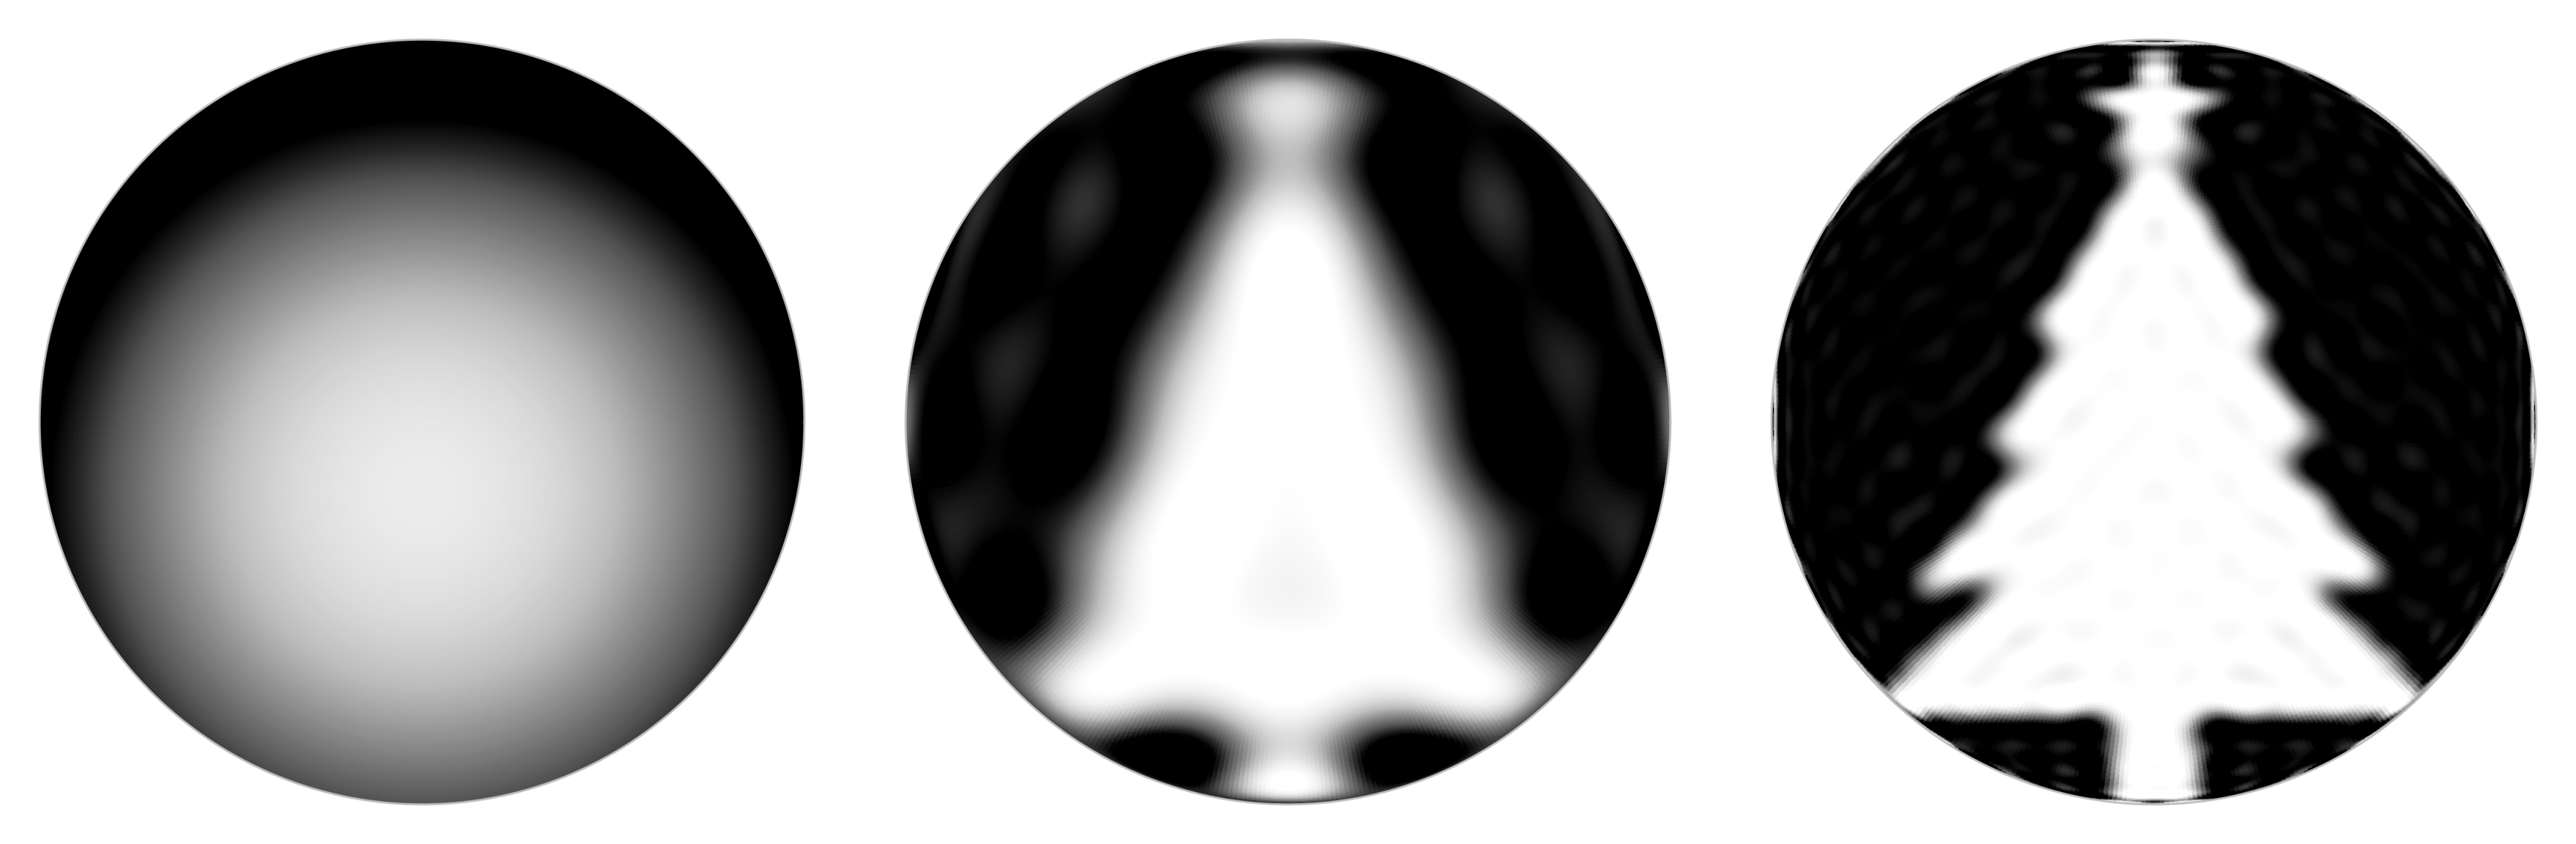

In [15]:
from PIL import Image
# Load images
img1 = Image.open("benchmarking_figures/christmas_tree/5.png")
img2 = Image.open("benchmarking_figures/christmas_tree/100.png")
img3 = Image.open("benchmarking_figures/christmas_tree/1000.png")

# Create side-by-side layout
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

axs[0].imshow(img1)
axs[1].imshow(img2)
axs[2].imshow(img3)

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.savefig("benchmarking_figures/trees.png")

In [3]:
import RW_helpers as RH
import Zernike_helpers as ZH
import Plot_helpers as PH
import Img_helpers as IH
import Booth_helpers as BH

In [4]:
N_order = 3               # 3 for 3P, 2 for 2P
lambd = 1.3/1000          # Wavelength [mm]
n = 1.3225                # Refractive index
k = (2*n*np.pi)/lambd       # Wavenumber
num_apt = 1.05            # Numerical aperture
length = 200                #mm
mag = 25                    # Magnification rate from input to objective
f = length/mag  # Focal length of objective (Nikon) [mm]
fwhm_pupil = 8.24 #[mm] 
na_eff = num_apt 
alpha = np.arcsin(na_eff / n)

In [13]:
L_ffp/res

80.0

In [5]:
L_ffp = 0.004
res = 0.05/1000
grid_ffp = int(L_ffp/res + 1)
theta_grid_size = 90

In [6]:
t_1 = time.time()
x_0, y_0, I_0 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order, None, "parallel_output/psf_output.npz")
t_2 = time.time()
print(f"Time elapsed: {np.round(t_2 - t_1, 3)}s")

Time elapsed: 7.121s


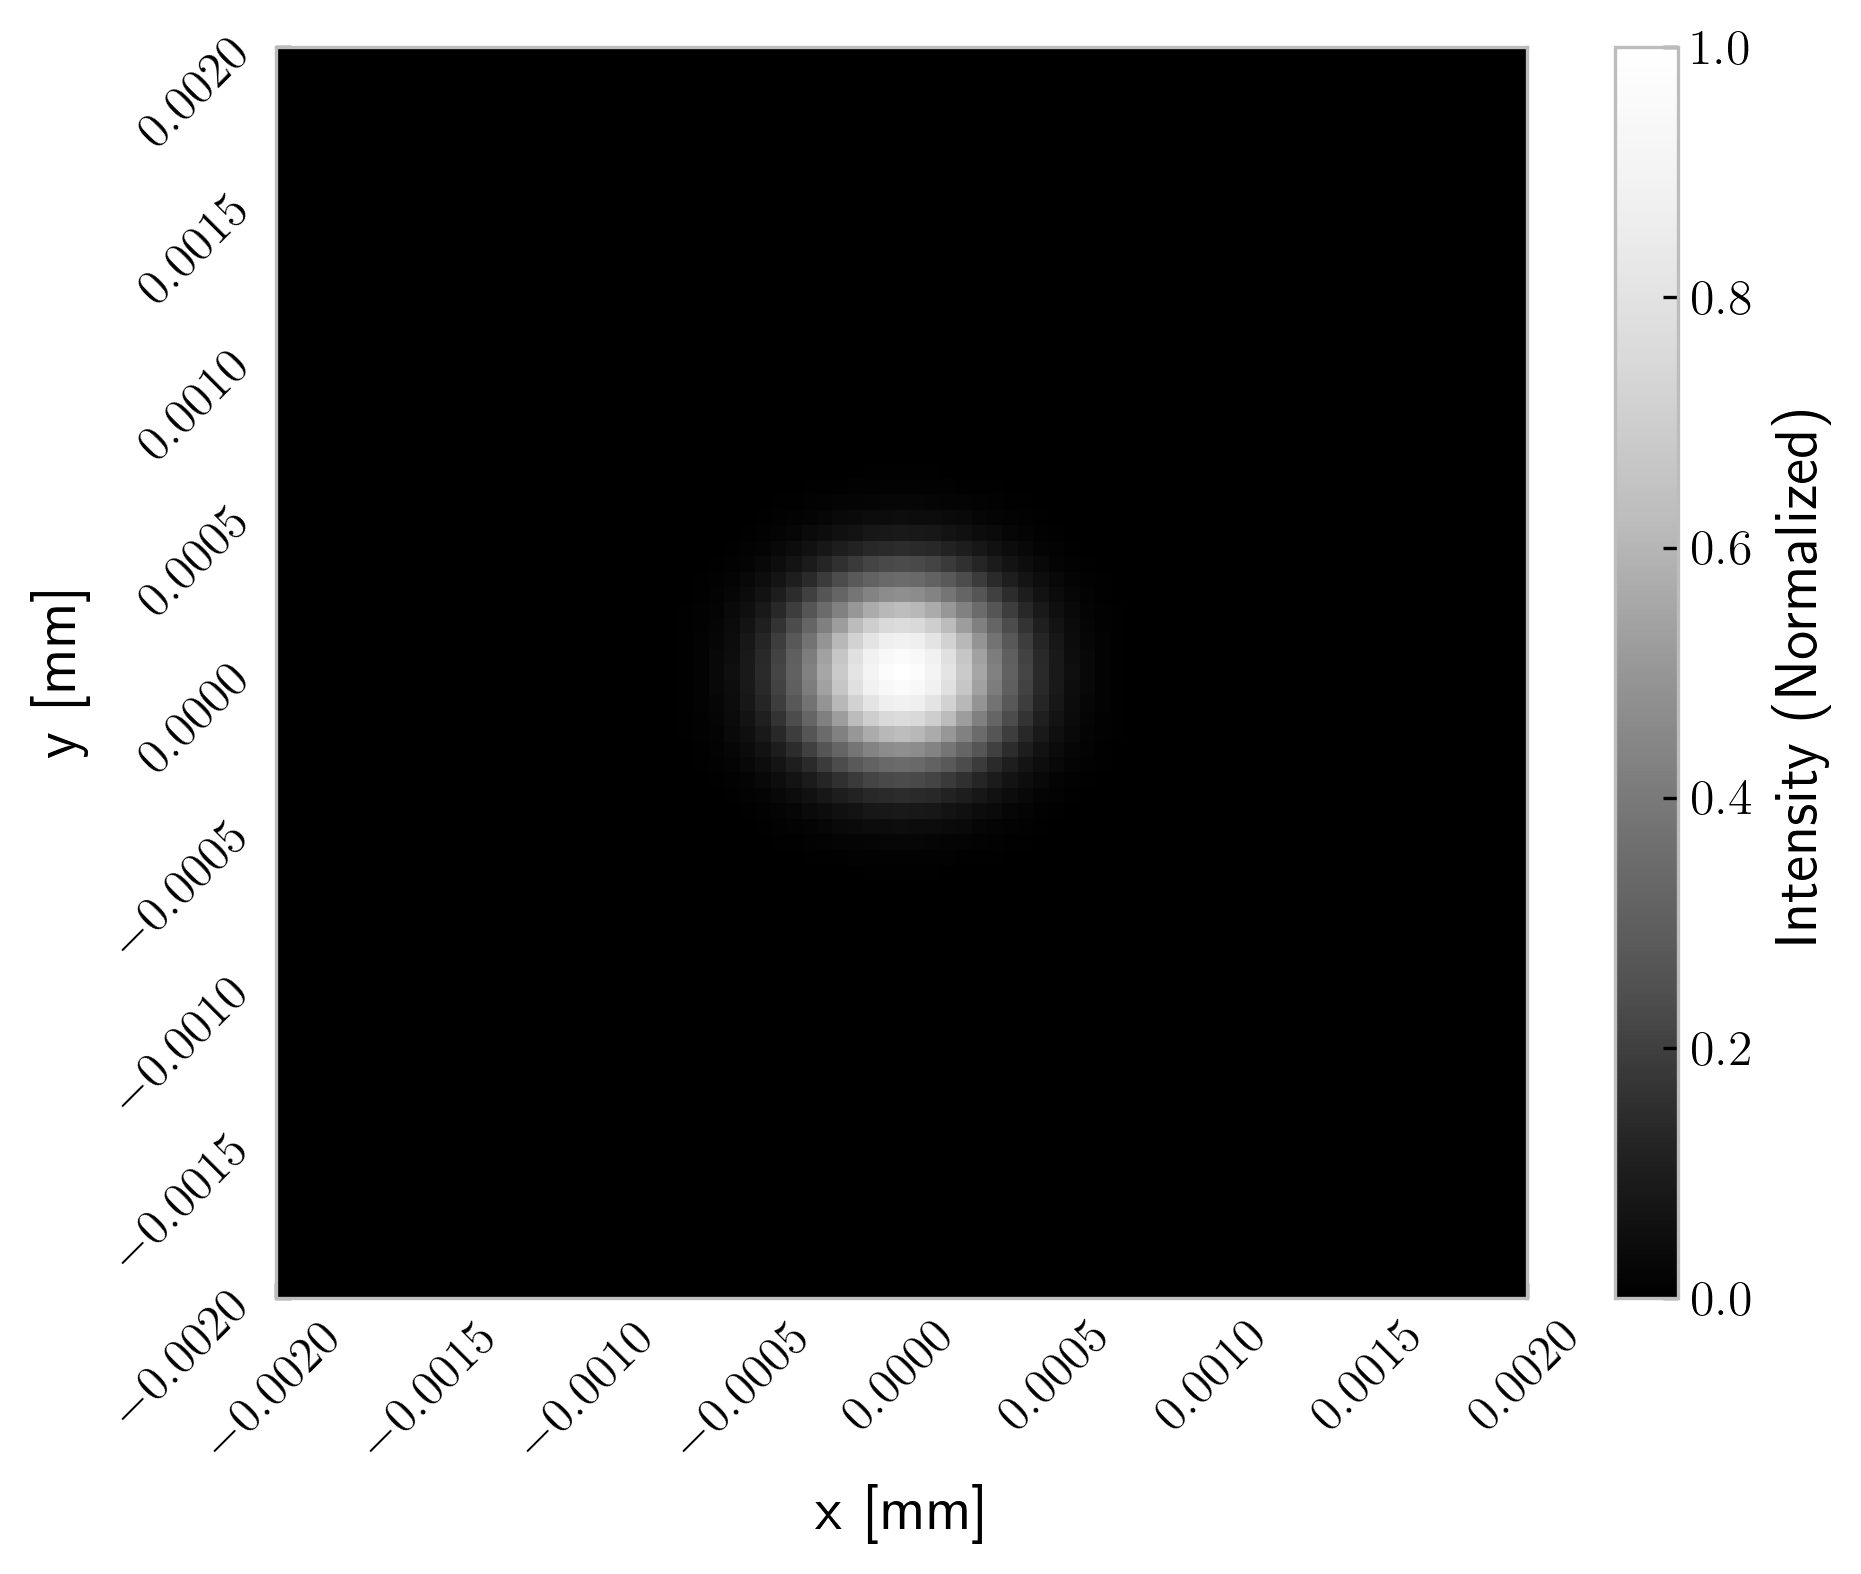

In [9]:
PH.plot_intensity(x_0, y_0, I_0, "basic_psf")

In [ ]:
theta_grid_sizes = [2, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 128, 256, 500]
xs = []
ys =[]
Is = []
for theta_grid_size in theta_grid_sizes:
    print("Theta:", theta_grid_size)
    t_1 = time.time()
    x, y, I = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order, None, "parallel_output/psf_output.npz")
    t_2 = time.time()
    xs.append(x)
    ys.append(y)
    Is.append(I)
    print(f"Time elapsed: {np.round(t_2 - t_1, 3)}s")

In [ ]:
I_best = Is[-1]/np.max(Is[-1])
errors = []
for i in range(len(Is) - 1):
    test_I = Is[i]/np.max(Is[i])
    MSE = np.sum((I_best - test_I)**2)
    errors.append(MSE)

In [ ]:
np.max(I_best)

In [ ]:
fig, ax = plt.subplots(dpi = 300)
ax.set_yscale("log")
ax.plot(theta_grid_sizes[1:-1], errors[1:], marker = "x")
ax.set_xlabel(f"Number of $\\theta, \phi$ Grid Elements")
ax.set_ylabel("PSF Mean Squared Error")
ax.set_title("Back Focal Plane Grid Integration")
plt.savefig("benchmarking_figures/bfp.png")

In [ ]:
fig, axs = plt.subplots(2, 3, dpi = 300, sharex = True, sharey = True, figsize = (548 / 72, 390 / 72))
thetas = [5, 90, 256]
for i, theta in enumerate(thetas):
    index = np.where(np.array(theta_grid_sizes) == theta)[0][0]
    intensity_map = Is[index]/np.max(Is[index])
    im = axs[0,i].imshow(intensity_map,
            extent=[x[0], x[-1], y[0], y[-1]],
        origin='lower',
        aspect = "equal",
        cmap='Greys_r')
    axs[0,i].grid(False)
    axs[0,i].tick_params(axis='both', labelrotation=45)
    axs[0,i].set_title(f"$n_\\theta, n_\\phi = {theta}$")
    if i ==0:
        axs[0,i].set_ylabel("y [mm]")
        axs[1,i].set_ylabel("y [mm]")
        
    residuals = intensity_map - I_best
    im_resid = axs[1,i].imshow(residuals, extent=[x[0], x[-1], y[0], y[-1]],
        origin='lower',
        aspect = "equal",
        cmap="RdBu_r",
         vmax = 0.01,
        vmin = -0.01 )
    axs[1,i].grid(False)
    axs[1,i].set_xlabel("x [mm]")
    axs[1,i].tick_params(axis='both', labelrotation=45)
    ticks = [-0.002, -0.001, 0.000, 0.001, 0.002]
    for k in range(0, 1):
        axs[k, i].set_xticks(ticks)
        axs[k, i].set_yticks(ticks)

fig.colorbar(
    im,
    ax=axs[0, :],
    label="Intensity",
    fraction=0.046,
    pad=0.04
)

fig.colorbar(
    im_resid,
    ax=axs[1, :],
    label="Residuals",
    fraction=0.046,
    pad=0.04
)

fig.subplots_adjust(hspace=0.03, right = 0.84)
plt.savefig("benchmarking_figures/bfp_images")

In [ ]:
L_ffp = 0.004
grid_ffp = int(4/0.05 + 1)
theta_grid_size = 90
#[[m,n],...]


In [16]:
zernike_modes = [[-1,1]]
zernike_strengths = [1.0]
x_1, y_1, I_1 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

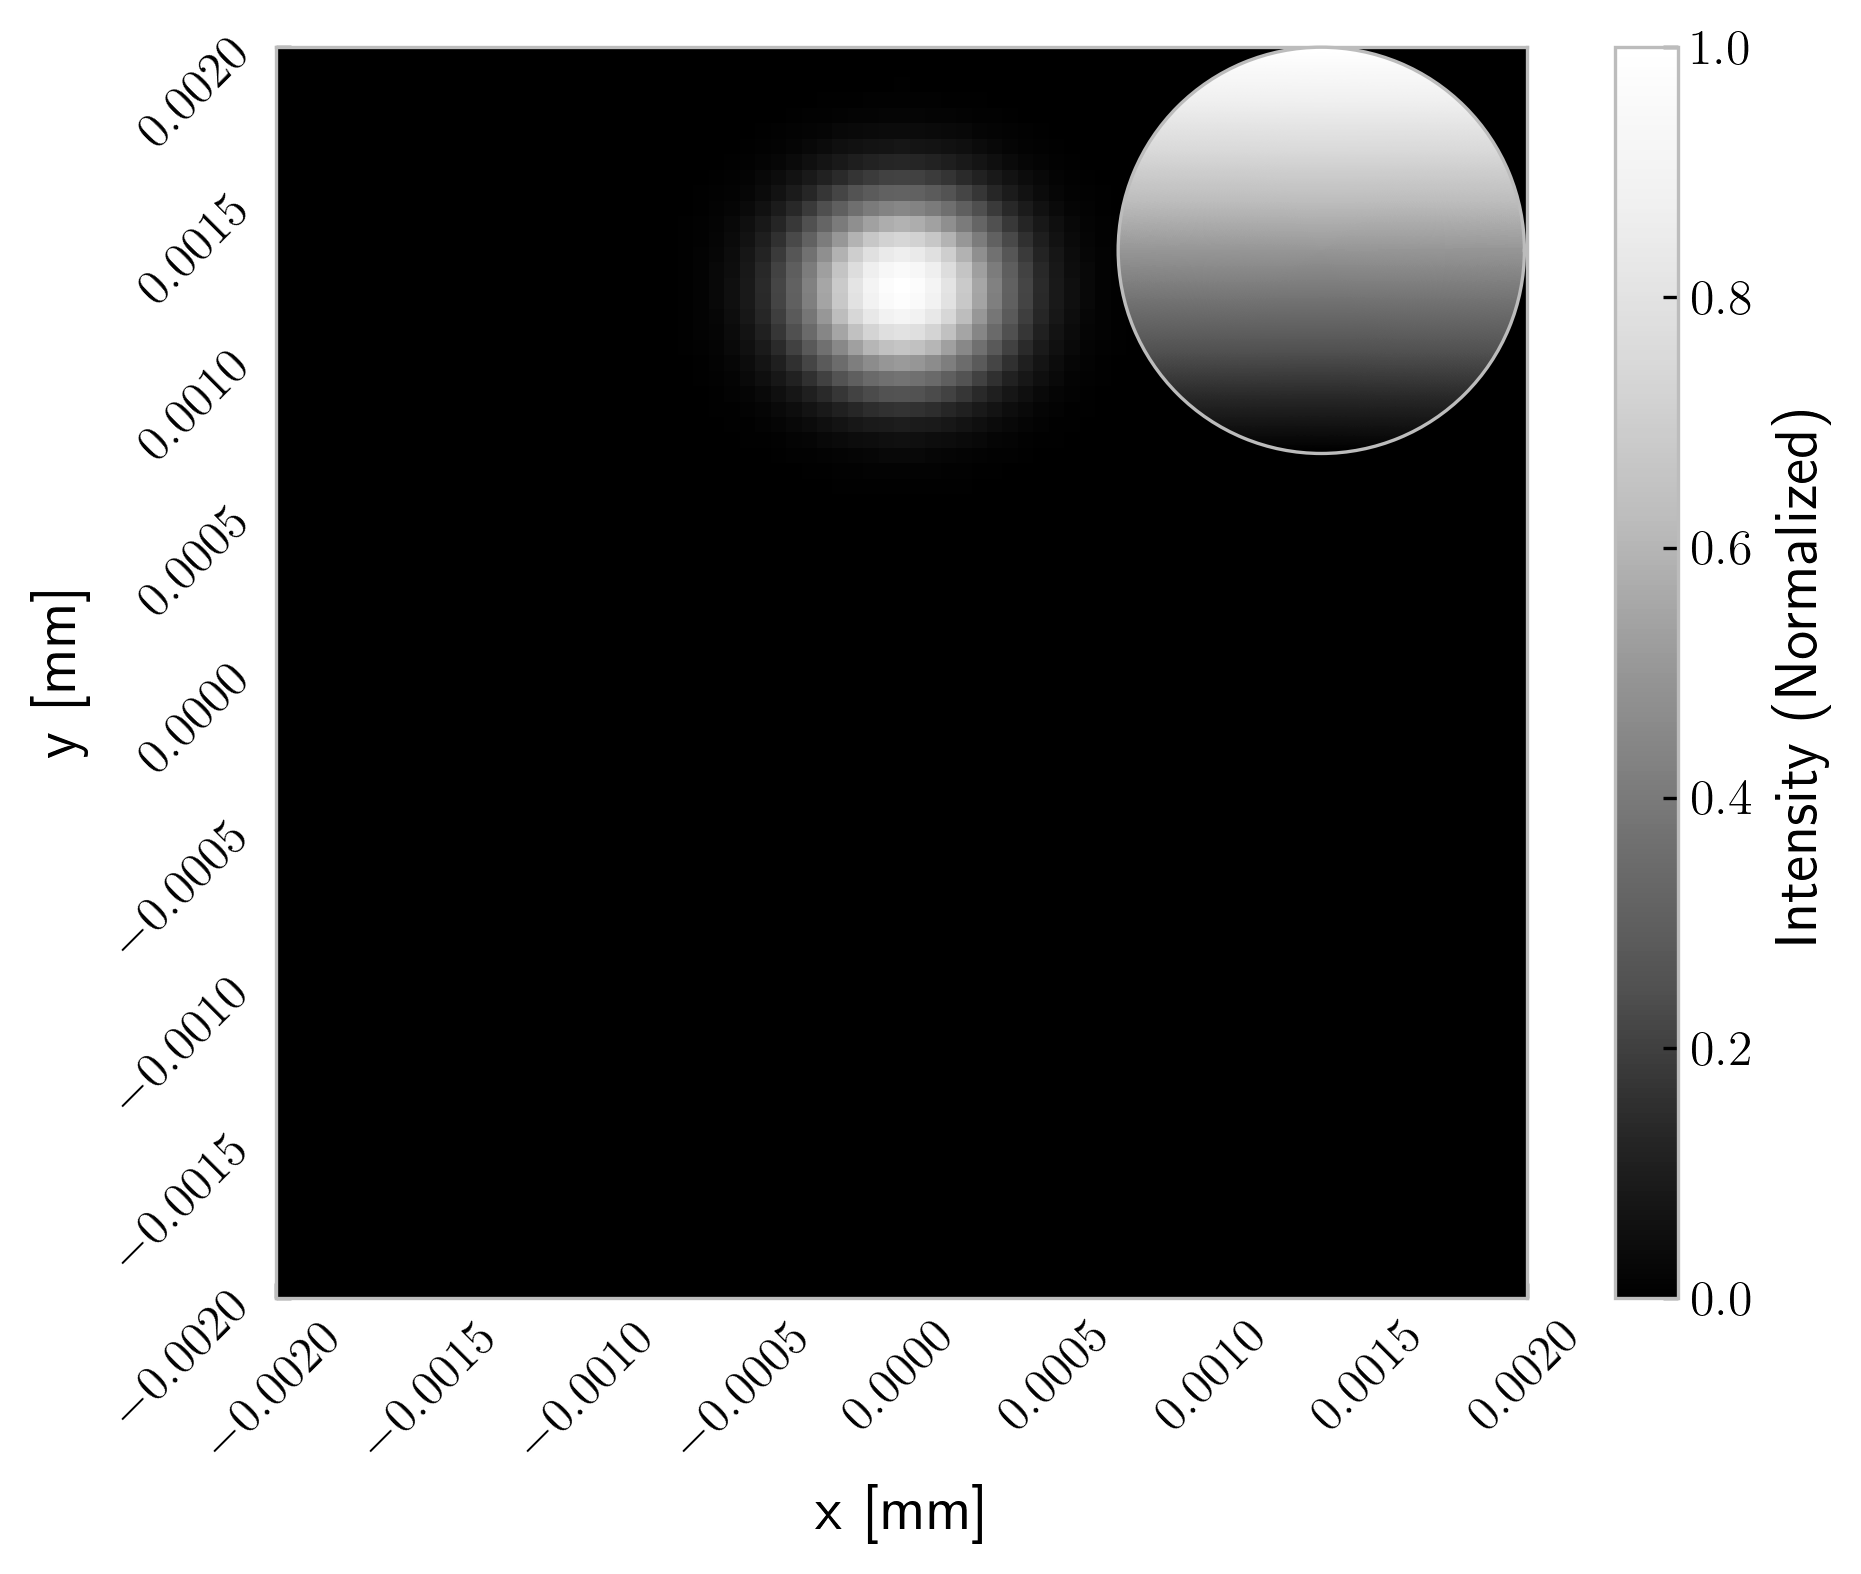

In [17]:
PH.composite_plot(x_1, y_1, I_1, z_map, alpha, "tilt_up")


In [18]:
zernike_modes = [[1,1]]
zernike_strengths = [1.0]
x_2, y_2, I_2 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

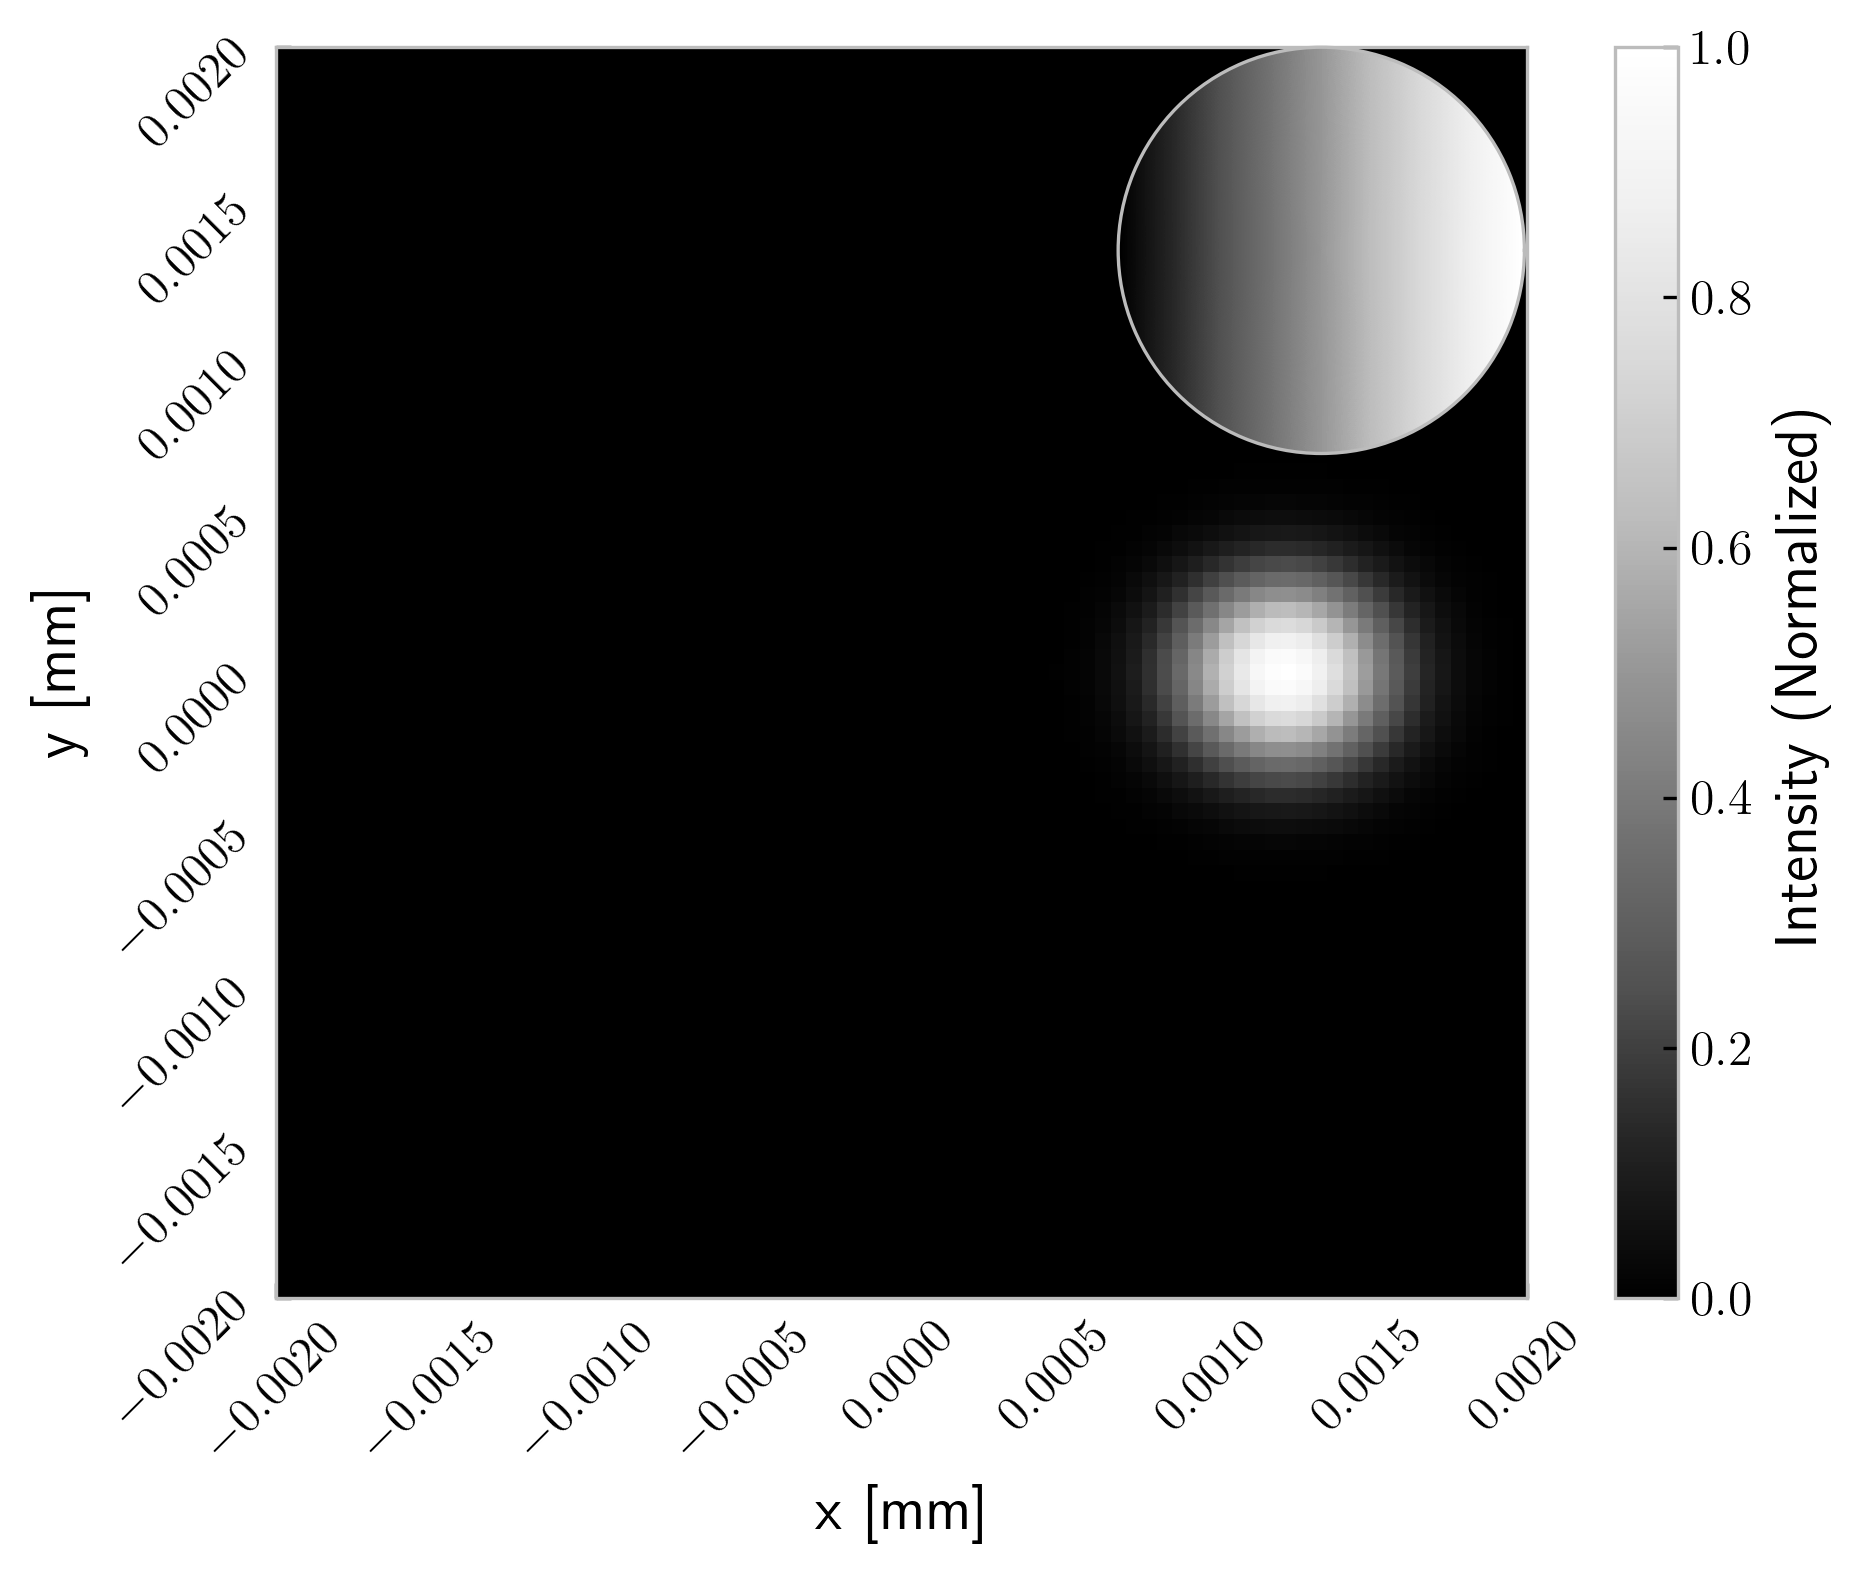

In [19]:
PH.composite_plot(x_2, y_2, I_2, z_map, alpha, "tilt_right")

In [20]:
zernike_modes = [[0,4]]
zernike_strengths = [1.0]
x_3, y_3, I_3 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

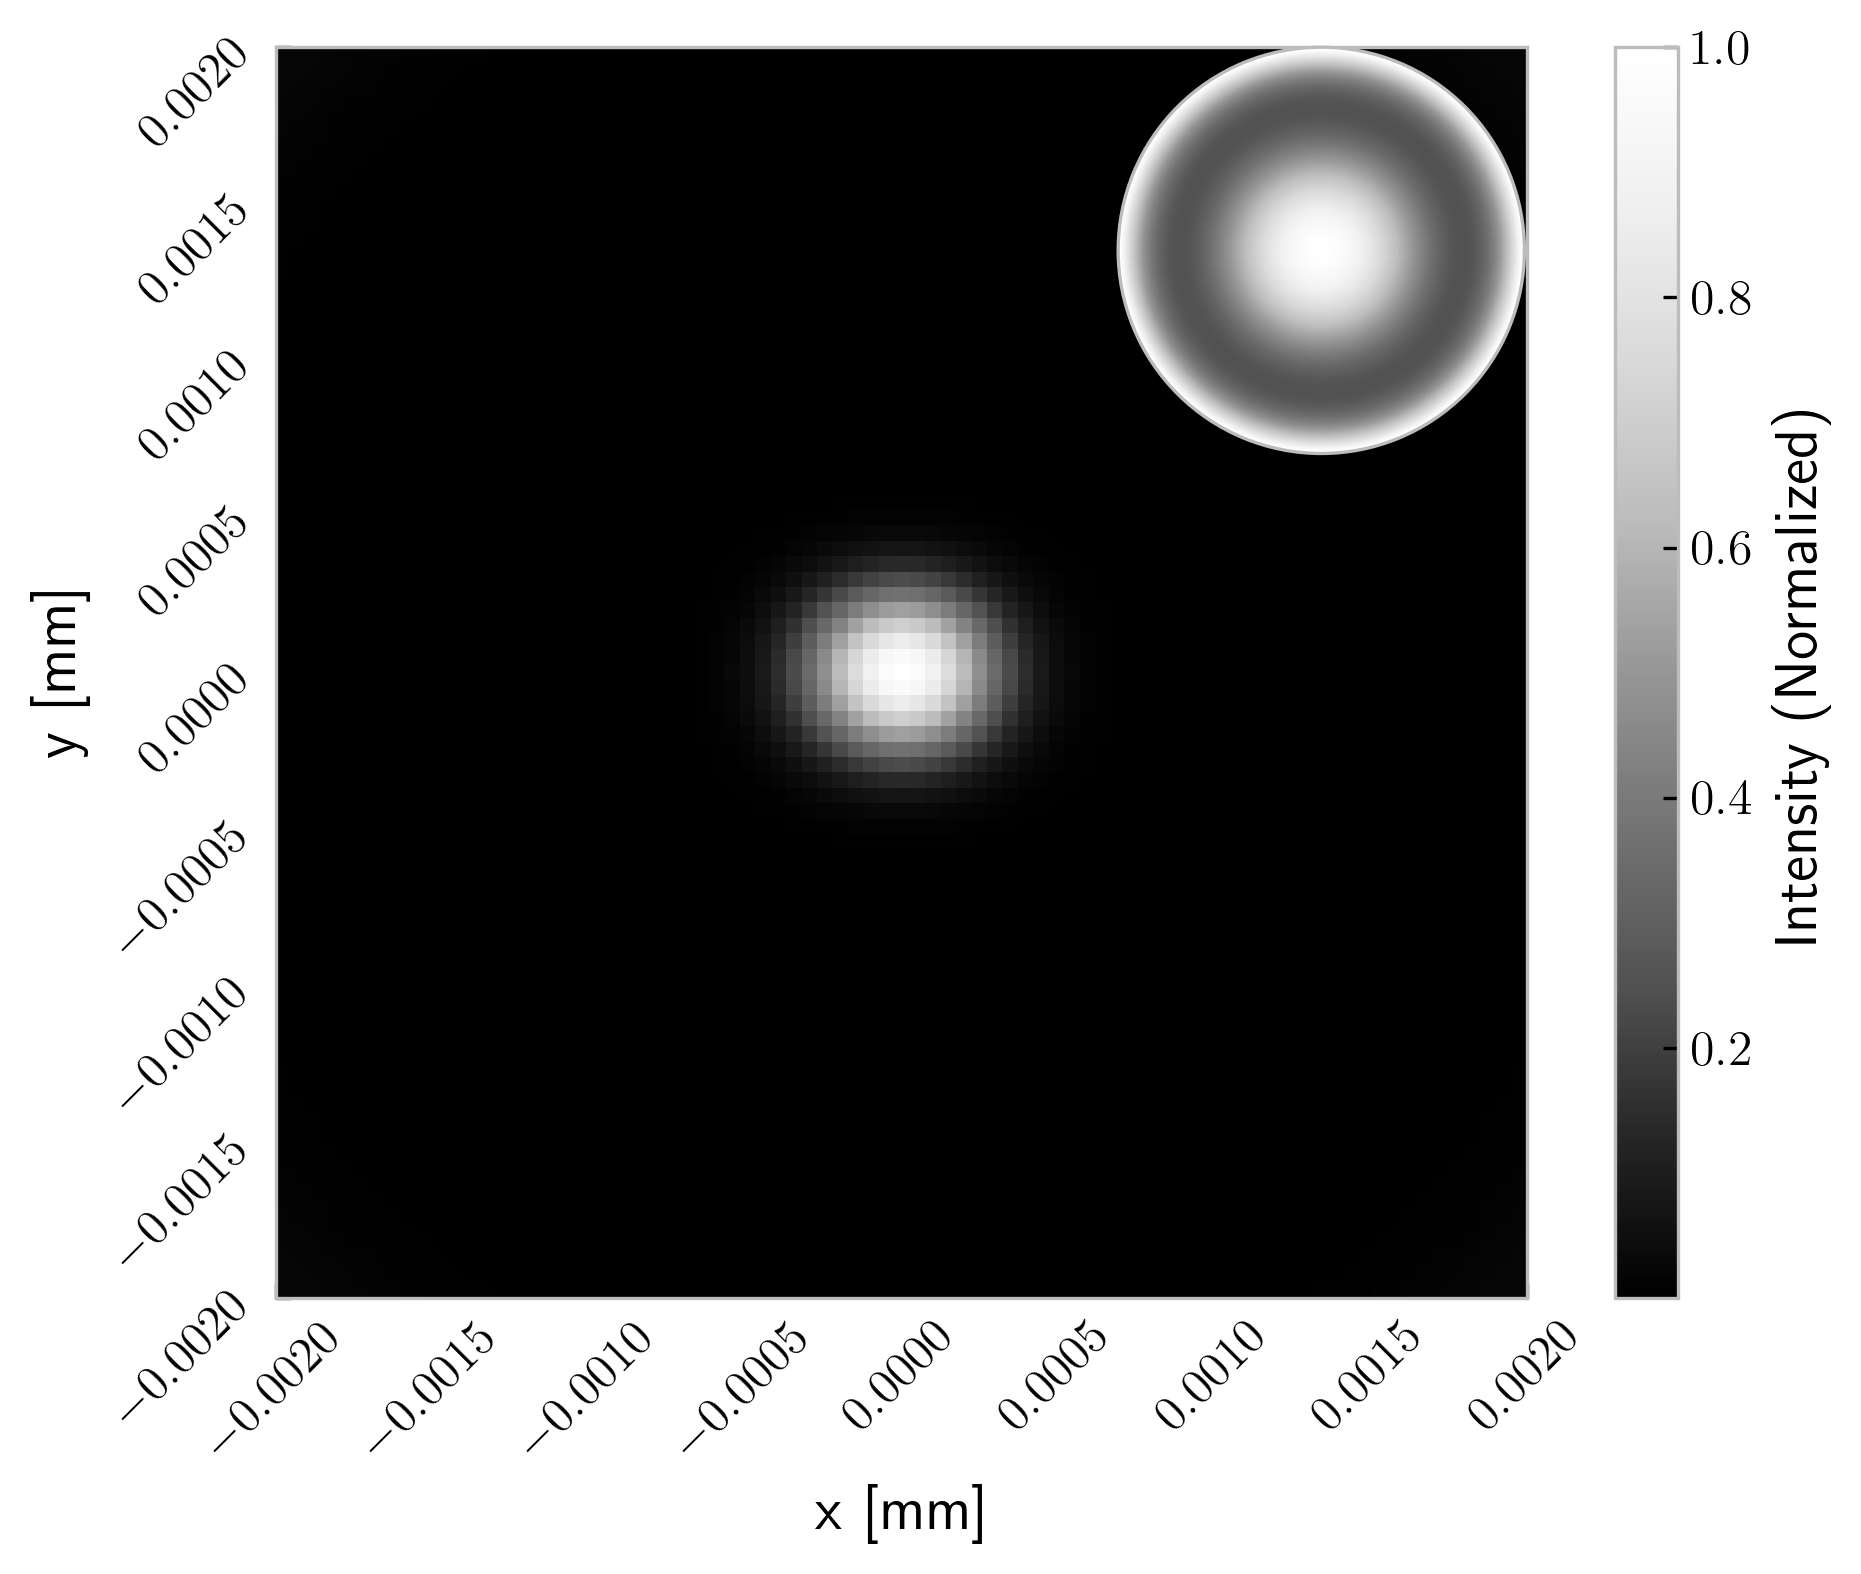

In [21]:
PH.composite_plot(x_3, y_3, I_3, z_map, alpha, "spherical")

In [22]:
zernike_modes = [[0,2]]
zernike_strengths = [1.0]
x_4, y_4, I_4 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

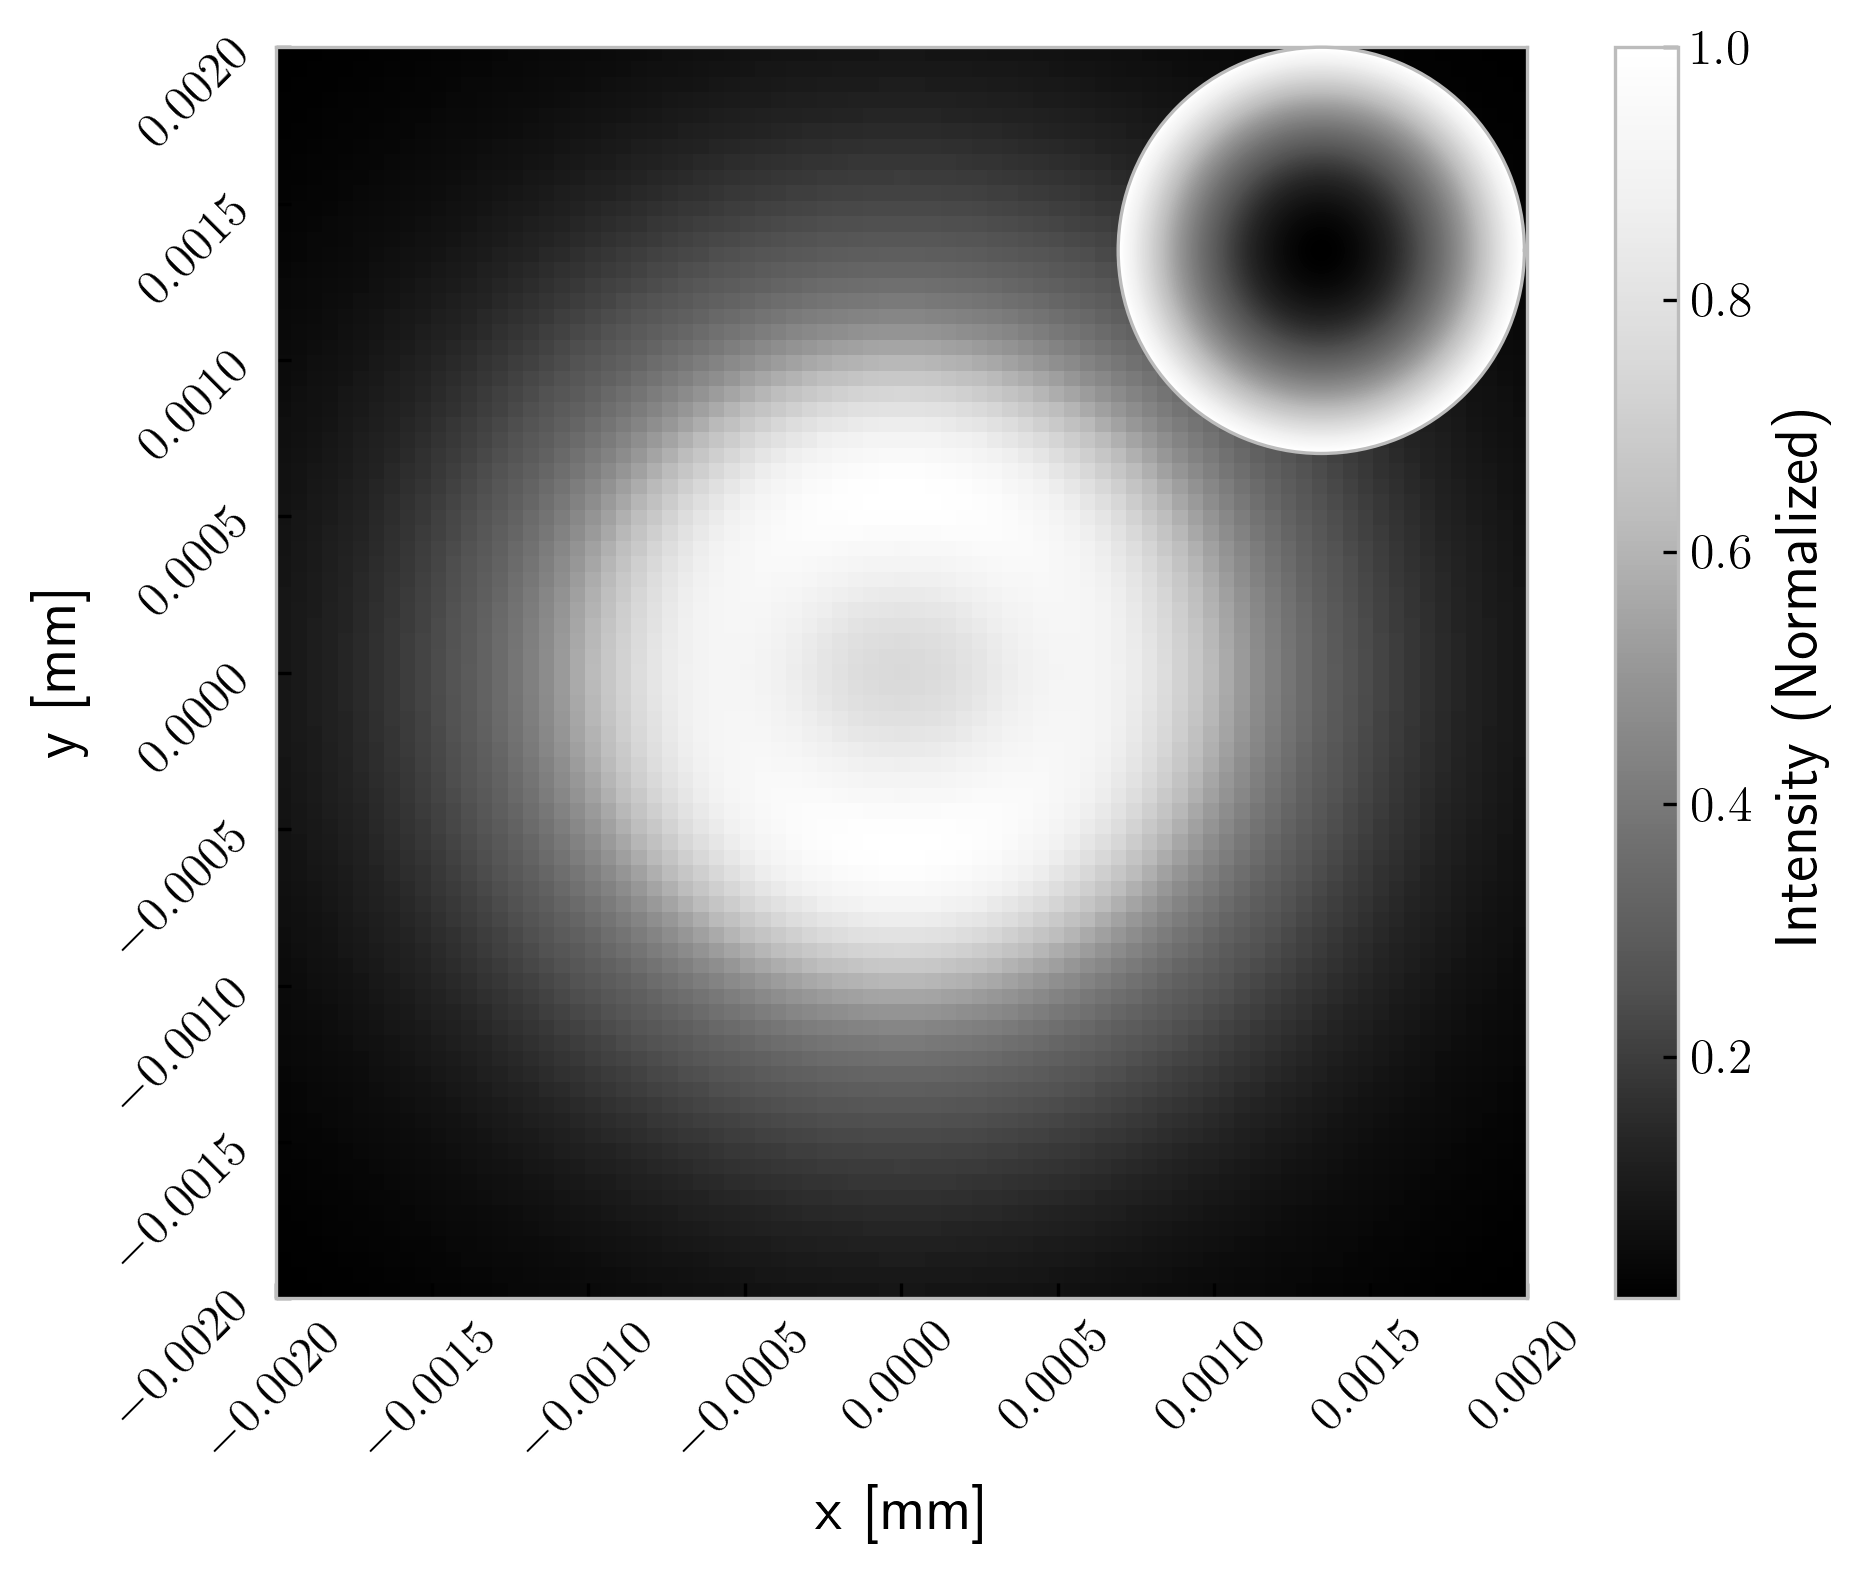

In [23]:
PH.composite_plot(x_4, y_4, I_4, z_map, alpha, "defocus")

In [24]:
zernike_modes = [[-3,3]]
zernike_strengths = [1.0]
x_5, y_5, I_5 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

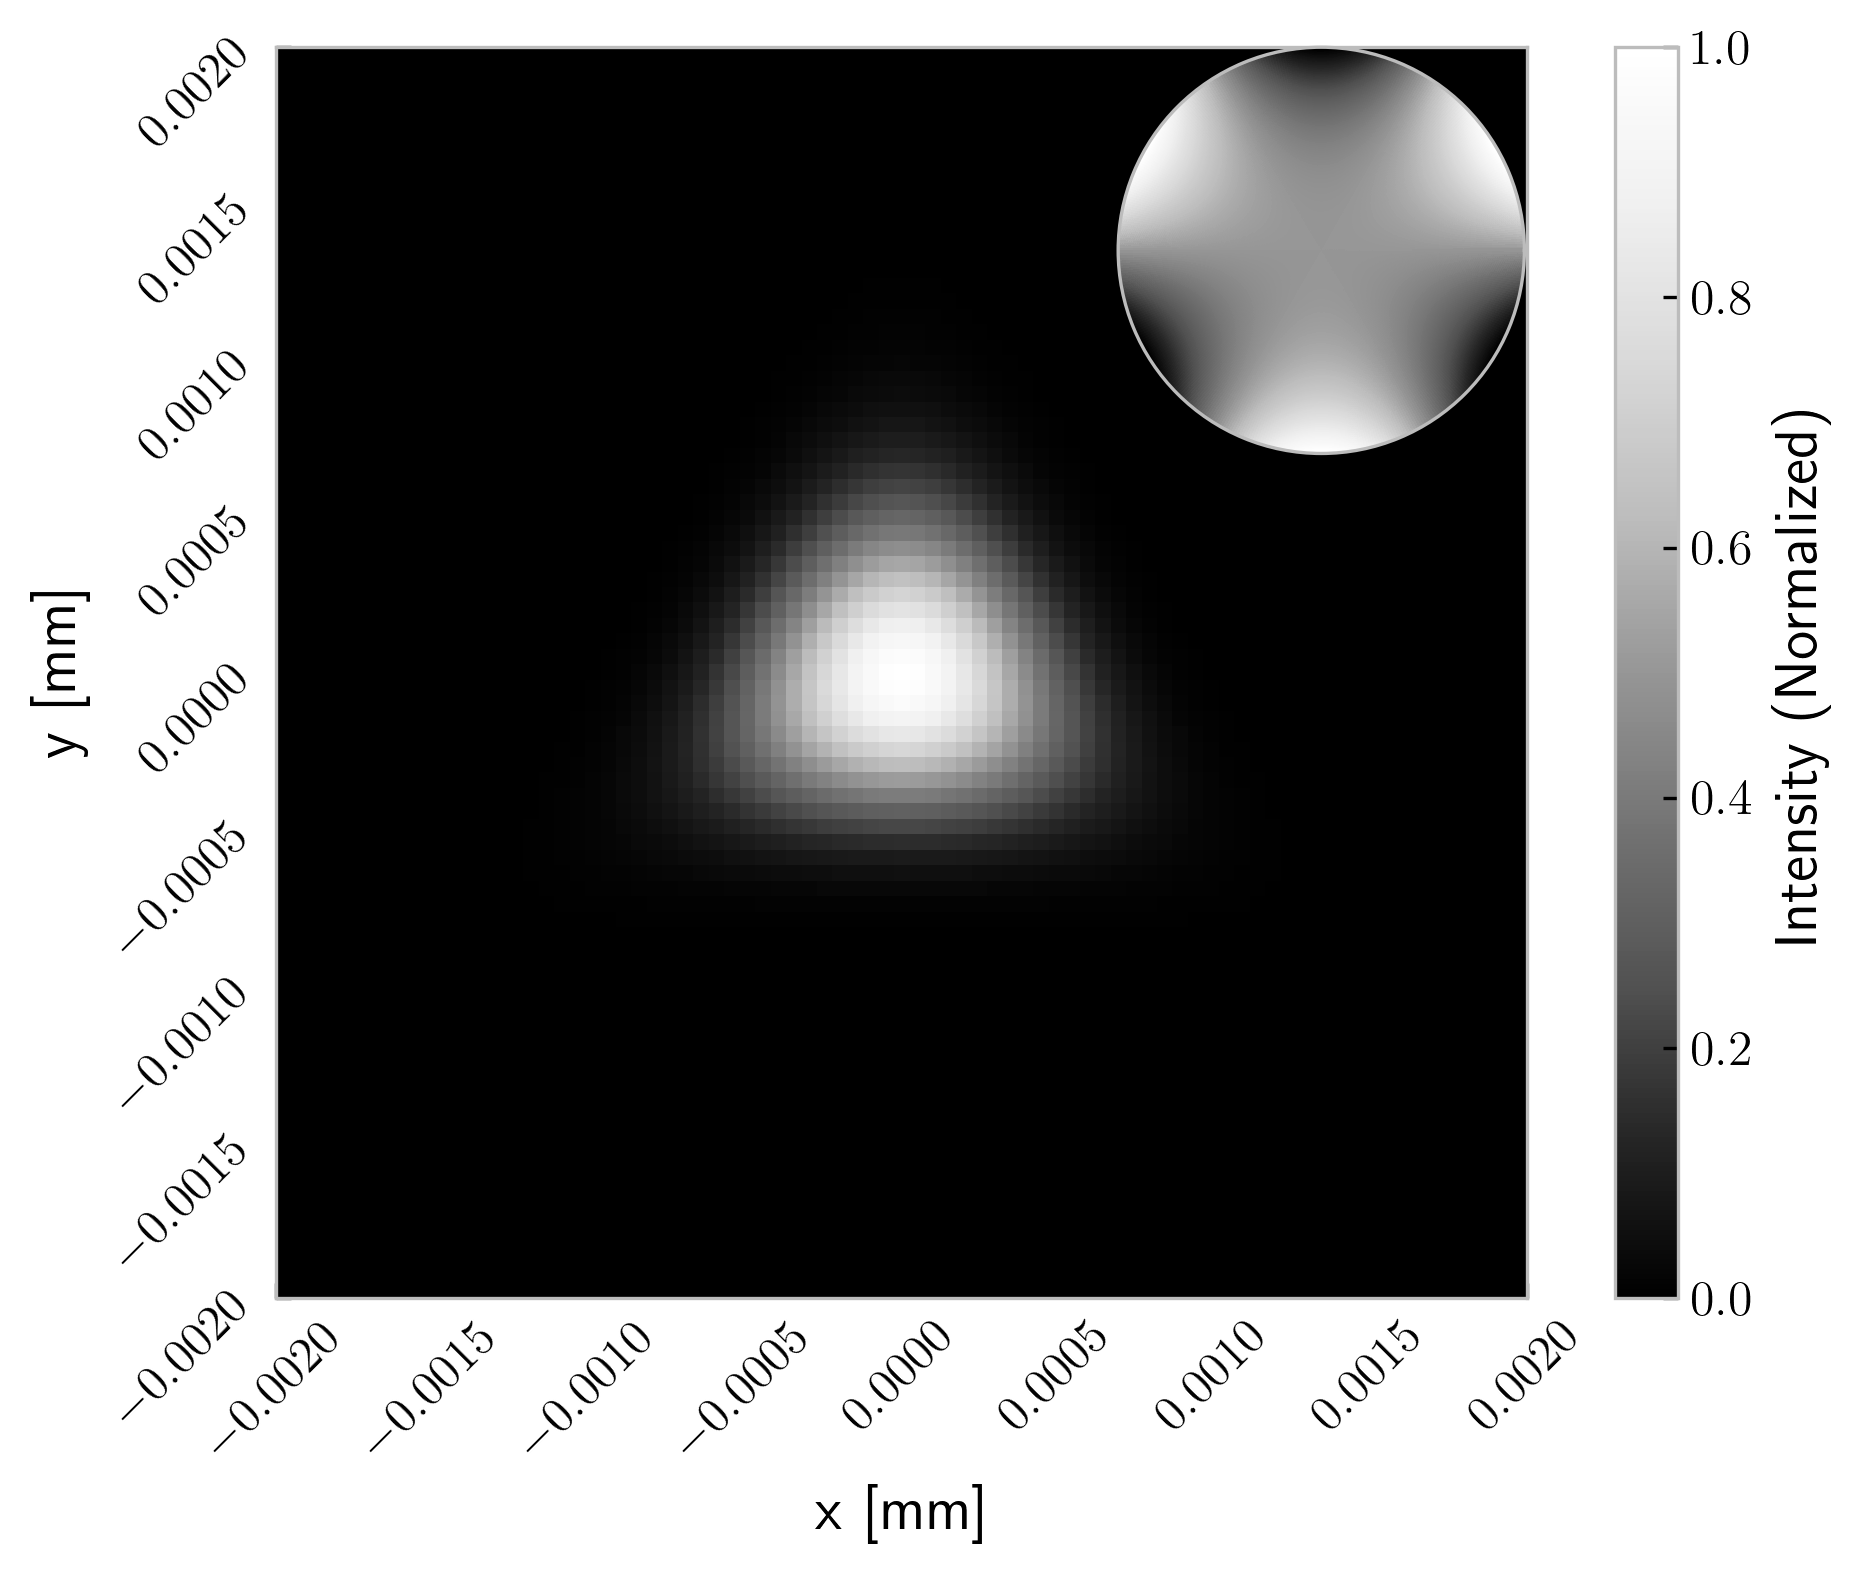

In [25]:
PH.composite_plot(x_5, y_5, I_5, z_map, alpha, "trefoil")

In [ ]:
bead_size = 0.0002

In [16]:
x_bead,y_bead, img_bead = IH.bead_img(L_ffp * 2, res, [0],[0], [bead_size])
PH.plot_intensity(x_bead, y_bead, IH.psf_convolve(img_bead,I_5))

NameError: name 'I_5' is not defined

In [ ]:
x,y, img = IH.random_bead_img(L_ffp * 2, res, 10, [bead_size]*10) 
PH.plot_intensity(x, y, IH.psf_convolve(img, I_5))

In [ ]:
x, y, img = IH.cell(L_ffp * 2, res, 10) 


In [ ]:
PH.plot_intensity(x, y, img)

In [ ]:
zernike_modes = [[-3,3]]
zernike_strengths = [1.0]
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)
PH.composite_plot(x, y, IH.psf_convolve(img, I_5), z_map, alpha, "voronoi_trefoil")

In [ ]:
IH.quality(IH.psf_convolve(img, I_0))

In [ ]:
IH.quality(IH.psf_convolve(img, I_5))

In [ ]:
zernike_modes = []
zernike_strengths = []
z_map = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)
PH.composite_plot(x, y, IH.psf_convolve(img, I_0), z_map, alpha, "voronoi_none")

In [ ]:
seed = 178
num_orders = 8
scaling = 0.5
modes, strengths = ZH.generate_random_aberration(seed, num_orders, scaling)
print(modes)
print(strengths)
x_c, y_c, I_c = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [modes, strengths])
z_map = ZH.create_zernike_function(modes, strengths, alpha)
PH.composite_plot(x_c, y_c, I_c, z_map, alpha)

In [ ]:
PH.composite_plot(x, y, IH.convolve(img, I_c), z_map, alpha, "voronoi_random")

In [ ]:
modes = [[0,0],[-1,1], [1,1], [-2,2], [0,2], [2,2]]
strengths = [0.5, 0.4, 0.9, -0.5, 0.7, -0.2]
z_map = ZH.create_zernike_function(modes, strengths, alpha)

In [ ]:
ZH.decompose_wavefront(z_map, alpha, 3)

Understanding the landscape for individual aberrations

In [ ]:
p_strengths = np.linspace(-0.5, 0.5, 51)
p_modes = [[2,2],
           [-2,2],
           [1,3],
           [-1,3],
           [3,3],
           [-3,3],
           [0,4],
           [2,4],
           [-2,4],
           [4,4],
           [-4,4]]
for mode in p_modes:
    for strength in tqdm(p_strengths):
        modes = [mode]
        strengths = [float(strength)]
        x_c, y_c, I_c = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [modes, strengths])
        np.save(f"psfs/{str(mode)}_{str(np.round(strength, 2))}", I_c/np.sum(I_c))

In [49]:
seed = 64
bead_size = 0.0002
x, y, single_bead_img = IH.bead_img(L_ffp * 3, res, [0], [0], [bead_size])
x, y, many_bead_img = IH.random_bead_img(L_ffp * 3, res, 30, [bead_size] * 30, seed)
x, y, cell_img = IH.cell(L_ffp * 3, res, 30, seed)

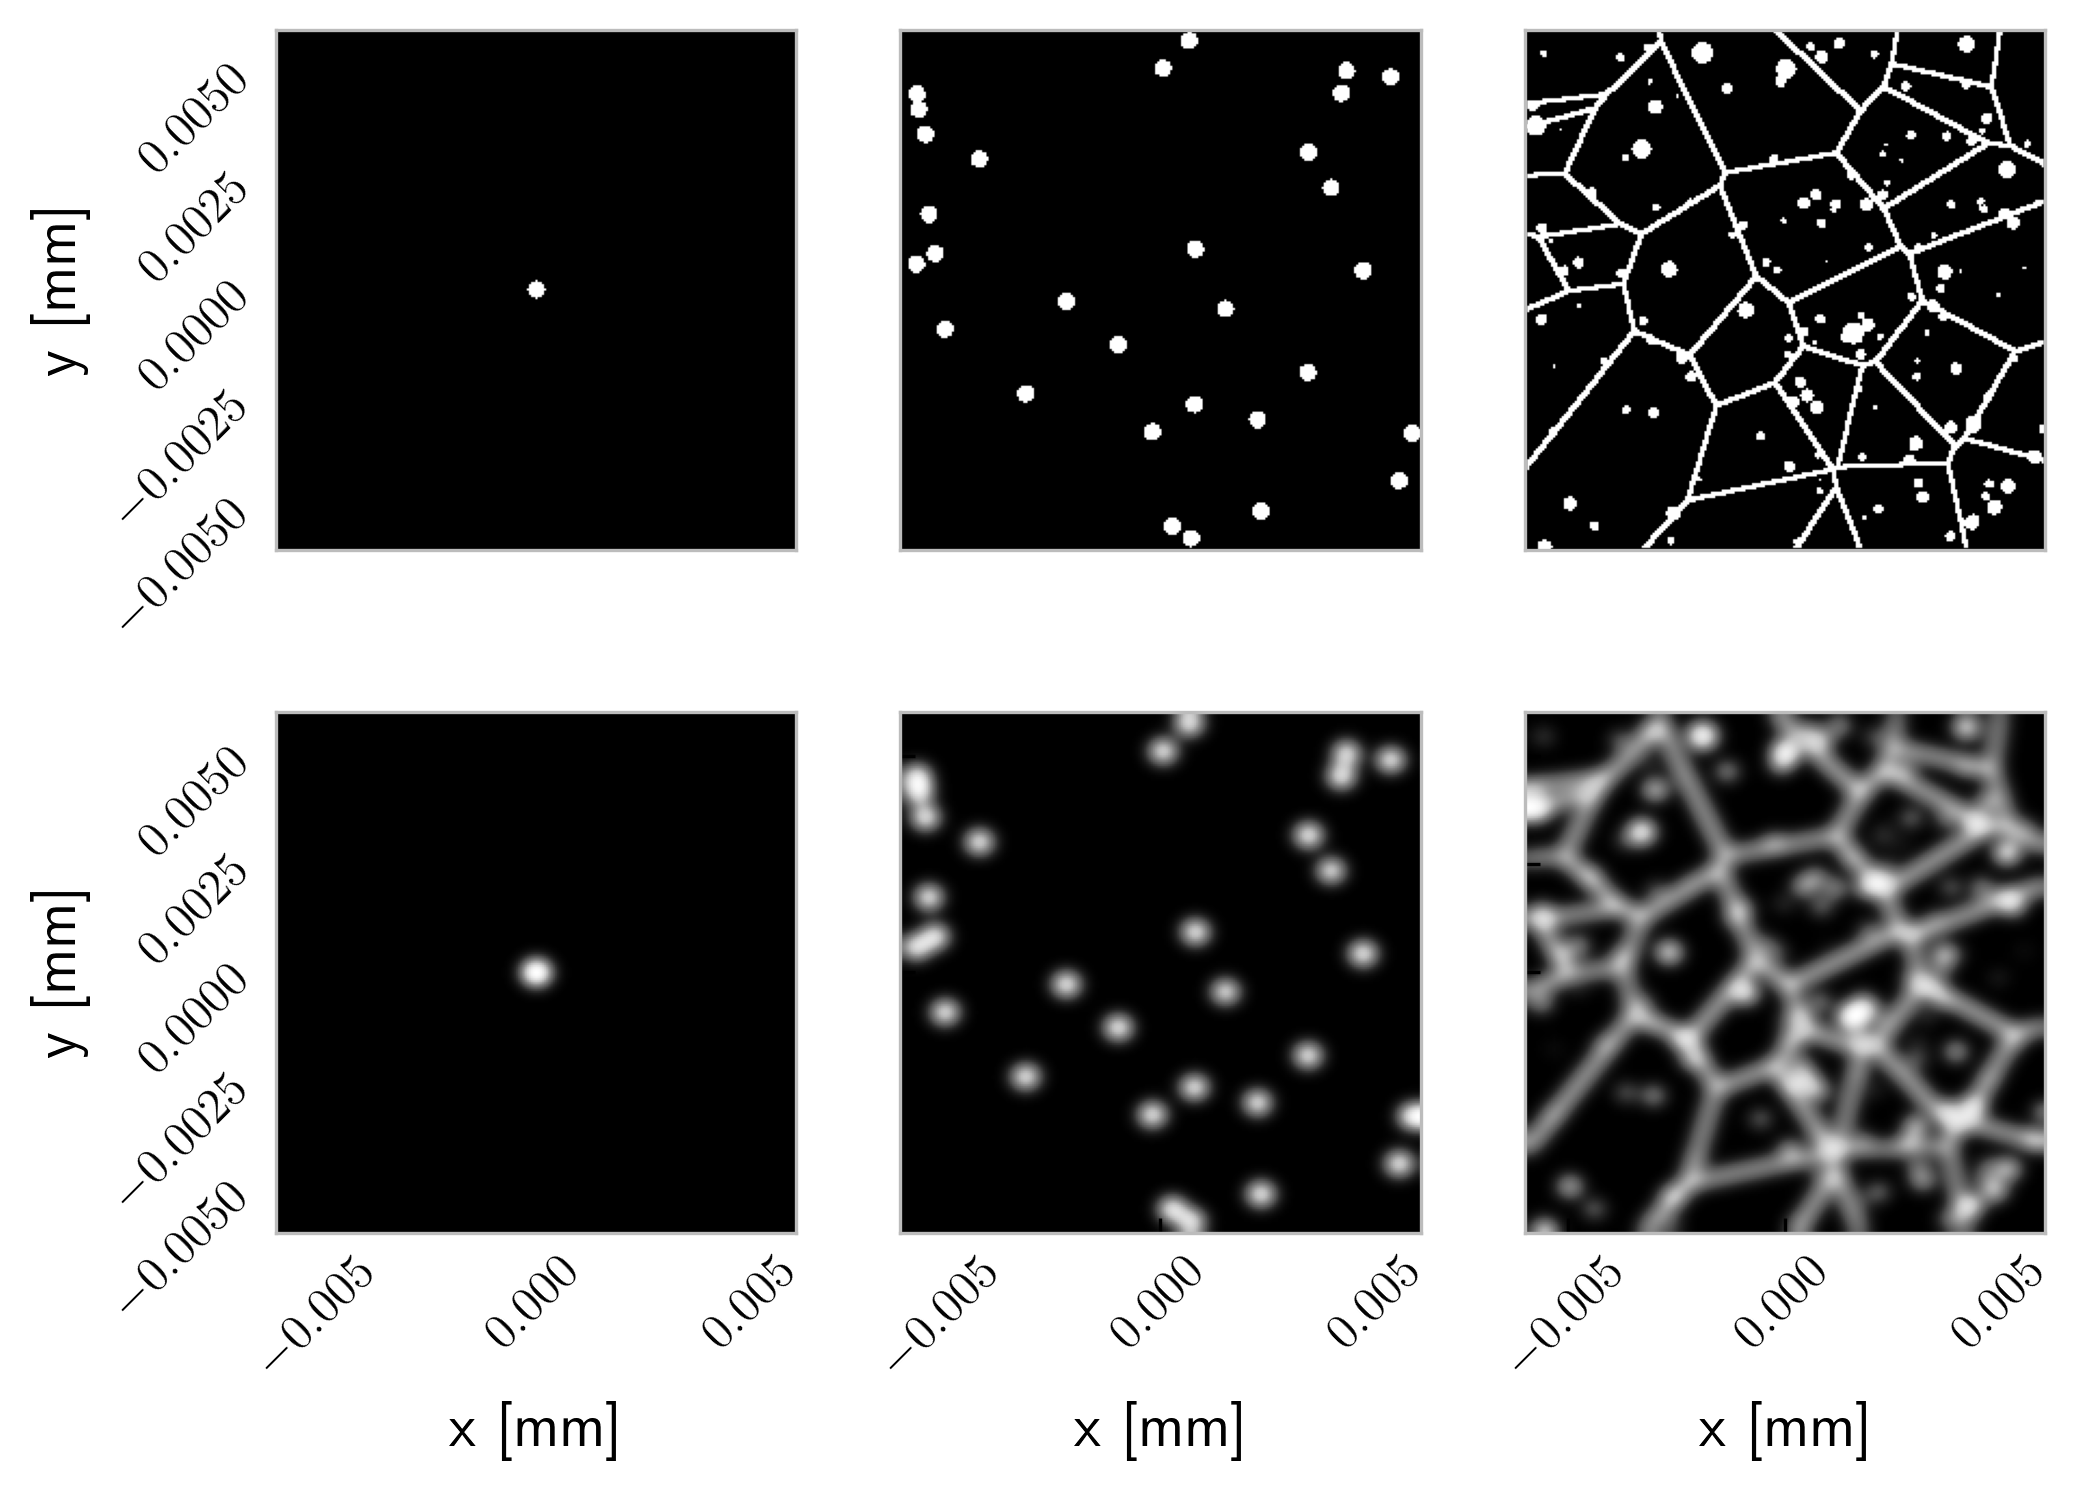

In [60]:
fig, axs = plt.subplots(2, 3, sharey = True, sharex = True)
PH.plot_many_intensity(axs[0], x, y, [single_bead_img, many_bead_img, cell_img], is_edge = False, is_horizontal = True)
PH.plot_many_intensity(axs[1], x, y, [IH.convolve(i, I_0) for i in [single_bead_img, many_bead_img, cell_img]], is_edge = True, is_horizontal = True)

for ax in axs[0]:
    ax.set_xlabel("")
plt.savefig("benchmarking_figures/sample_images.png", bbox_inches = "tight")

In [ ]:
n_modes = 11
n_strengths = 51
#single fluorobead, many fluorobeads, biological looking
n_images = 3
metrics = np.zeros(shape = (n_modes, n_strengths, n_images))
for i, mode in enumerate(p_modes):
    for j, strength in tqdm(enumerate(p_strengths)):
        psf = np.load(f"psfs/{str(mode)}_{str(np.round(strength, 2))}.npy")
        for k, img in enumerate([single_bead_img, many_bead_img, cell_img]):
            convolved = IH.convolve(img, psf)
            quality = IH.quality(convolved)
            metrics[i,j,k] = quality
np.save("benchmarking_figures/metrics", metrics)

In [ ]:
fig, axs = plt.subplots(1, 3, sharey=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
titles = ["Single Bead", "Many Beads", "Pseudo-Bio"]
for j, mode in enumerate(p_modes):
    color = colors[j % len(colors)]

    for i in range(n_images):
        label = rf"$Z^{{{mode[0]}}}_{{{mode[1]}}}$" if i == 0 else None
        axs[i].plot(
            p_strengths,
            metrics[j, :, i] / metrics[j, int(51/2), i],
            color=color,
            label=label
        )
        axs[i].set_title(titles[i])
        axs[i].set_xlabel("Aberration [waves]")
axs[0].set_ylabel("Image Metric $M$")
fig.legend(
    loc="lower right",
    bbox_to_anchor=(0.87, 0.15),   # (x, y) in figure coordinates
    ncol=3,             # horizontal legend
    frameon=True,
    framealpha=0.9,        # 0 = fully transparent, 1 = fully opaque
    facecolor="white",    # optional, but usually best
    edgecolor="0.3"       # optional, subtle outline
)
plt.savefig("benchmarking_figures/landscape.png")


In [ ]:
fig, axs = plt.subplots(3, 3, sharex = True, sharey = True)
empty_map = ZH.create_zernike_function([],[],alpha)
PH.many_composite(fig, axs[0], x, y, [IH.convolve(i, I_0) for i in [single_bead_img, many_bead_img, cell_img]],
                  [empty_map]*3, alpha)
mode = [-1, 3]
strength = -0.2
coma_map = ZH.create_zernike_function([mode], [strength], alpha)
PSF = np.load(f"psfs/{mode}_{np.round(strength, 2)}.npy")
PH.many_composite(fig, axs[1], x, y, [IH.convolve(i, PSF) for i in [single_bead_img, many_bead_img, cell_img]],
                       [coma_map]*3, alpha)
mode = [1, 3]
strength = -0.2
coma_map = ZH.create_zernike_function([mode], [strength], alpha)
PSF = np.load(f"psfs/{mode}_{np.round(strength, 2)}.npy")
PH.many_composite(fig, axs[1], x, y, [IH.convolve(i, PSF) for i in [single_bead_img, many_bead_img, cell_img]],
                       [coma_map]*3, alpha, vmin = -1, vmax = 1)
mode = [-1, 3]
strength = -0.2
coma_map = ZH.create_zernike_function([mode], [strength], alpha)
PSF = np.load(f"psfs/{mode}_{np.round(strength, 2)}.npy")
PH.many_composite(fig, axs[2], x, y, [IH.convolve(i, PSF) for i in [single_bead_img, many_bead_img, cell_img]],
                       [coma_map]*3, alpha, vmin = -1, vmax = 1, is_bottom = True)
plt.savefig("benchmarking_figures/coma.png")


Now the moment we've been waiting for!

In [14]:
mode = [-2, 2]
strength = 0.3
coma_map = ZH.create_zernike_function([mode], [strength], alpha)

prior = 0.0
bias = 0.2
#first image 
x,y, psf_0 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [[mode], [strength + prior]])
#minus image
x,y, psf_minus = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [[mode], [strength + prior - bias]])
#plus image 
x,y, psf_plus = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [[mode], [strength + prior + bias]])

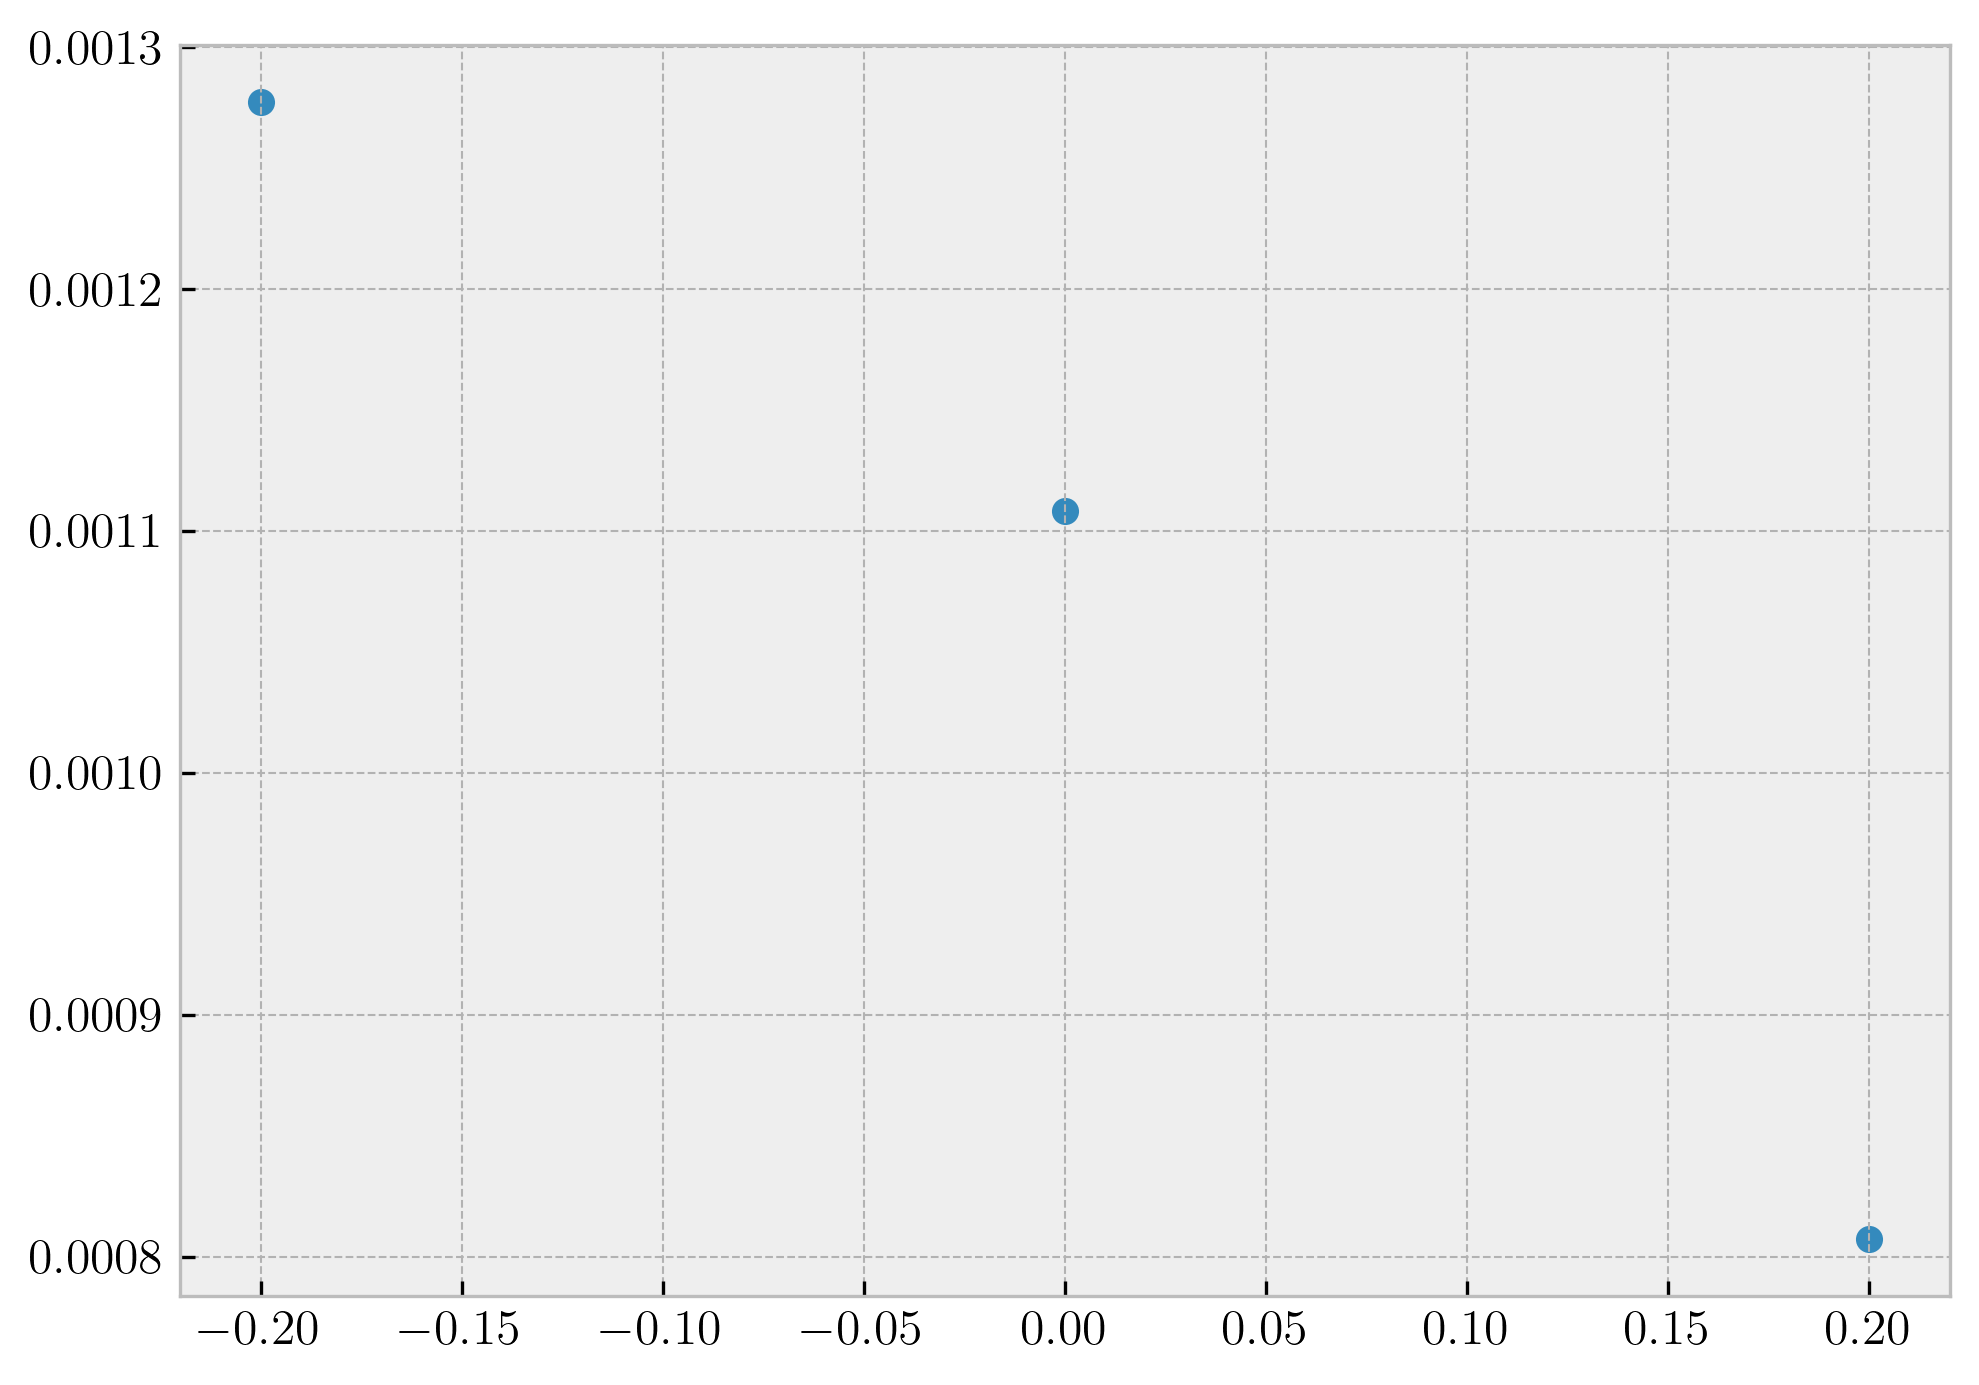

In [17]:
[bead_0, bead_minus, bead_plus] = [IH.psf_convolve(single_bead_img, psf) for psf in [psf_0, psf_minus, psf_plus]]
metrics = [IH.quality(image) for image in [bead_0, bead_minus, bead_plus]]
biases = [prior, prior-bias, prior+bias]
plt.scatter(biases, metrics)

In [19]:
[a, b, c] = np.polyfit(biases, metrics, 2, )

In [26]:
zernike_modes = [[1,3]]
zernike_strengths = [1.0]
x_1, y_1, I_1 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_1 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

In [27]:
zernike_modes = [[0, 2]]
zernike_strengths = [1.0]
x_2, y_2, I_2 = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_2 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

In [28]:
zernike_modes = [[4, 4]]
zernike_strengths = [1.0]
x_3, y_3, I_3= RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_3 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

In [36]:
zernike_modes = [[-1, 1]]
zernike_strengths = [1.0]
x_4, y_4, I_4= RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_4 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

zernike_modes = [[1, 1]]
zernike_strengths = [1.0]
x_5, y_5, I_5= RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_5 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

zernike_modes = [[-2, 2]]
zernike_strengths = [1.0]
x_6, y_6, I_6= RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [zernike_modes, zernike_strengths])
z_map_6 = ZH.create_zernike_function(zernike_modes, zernike_strengths, alpha)

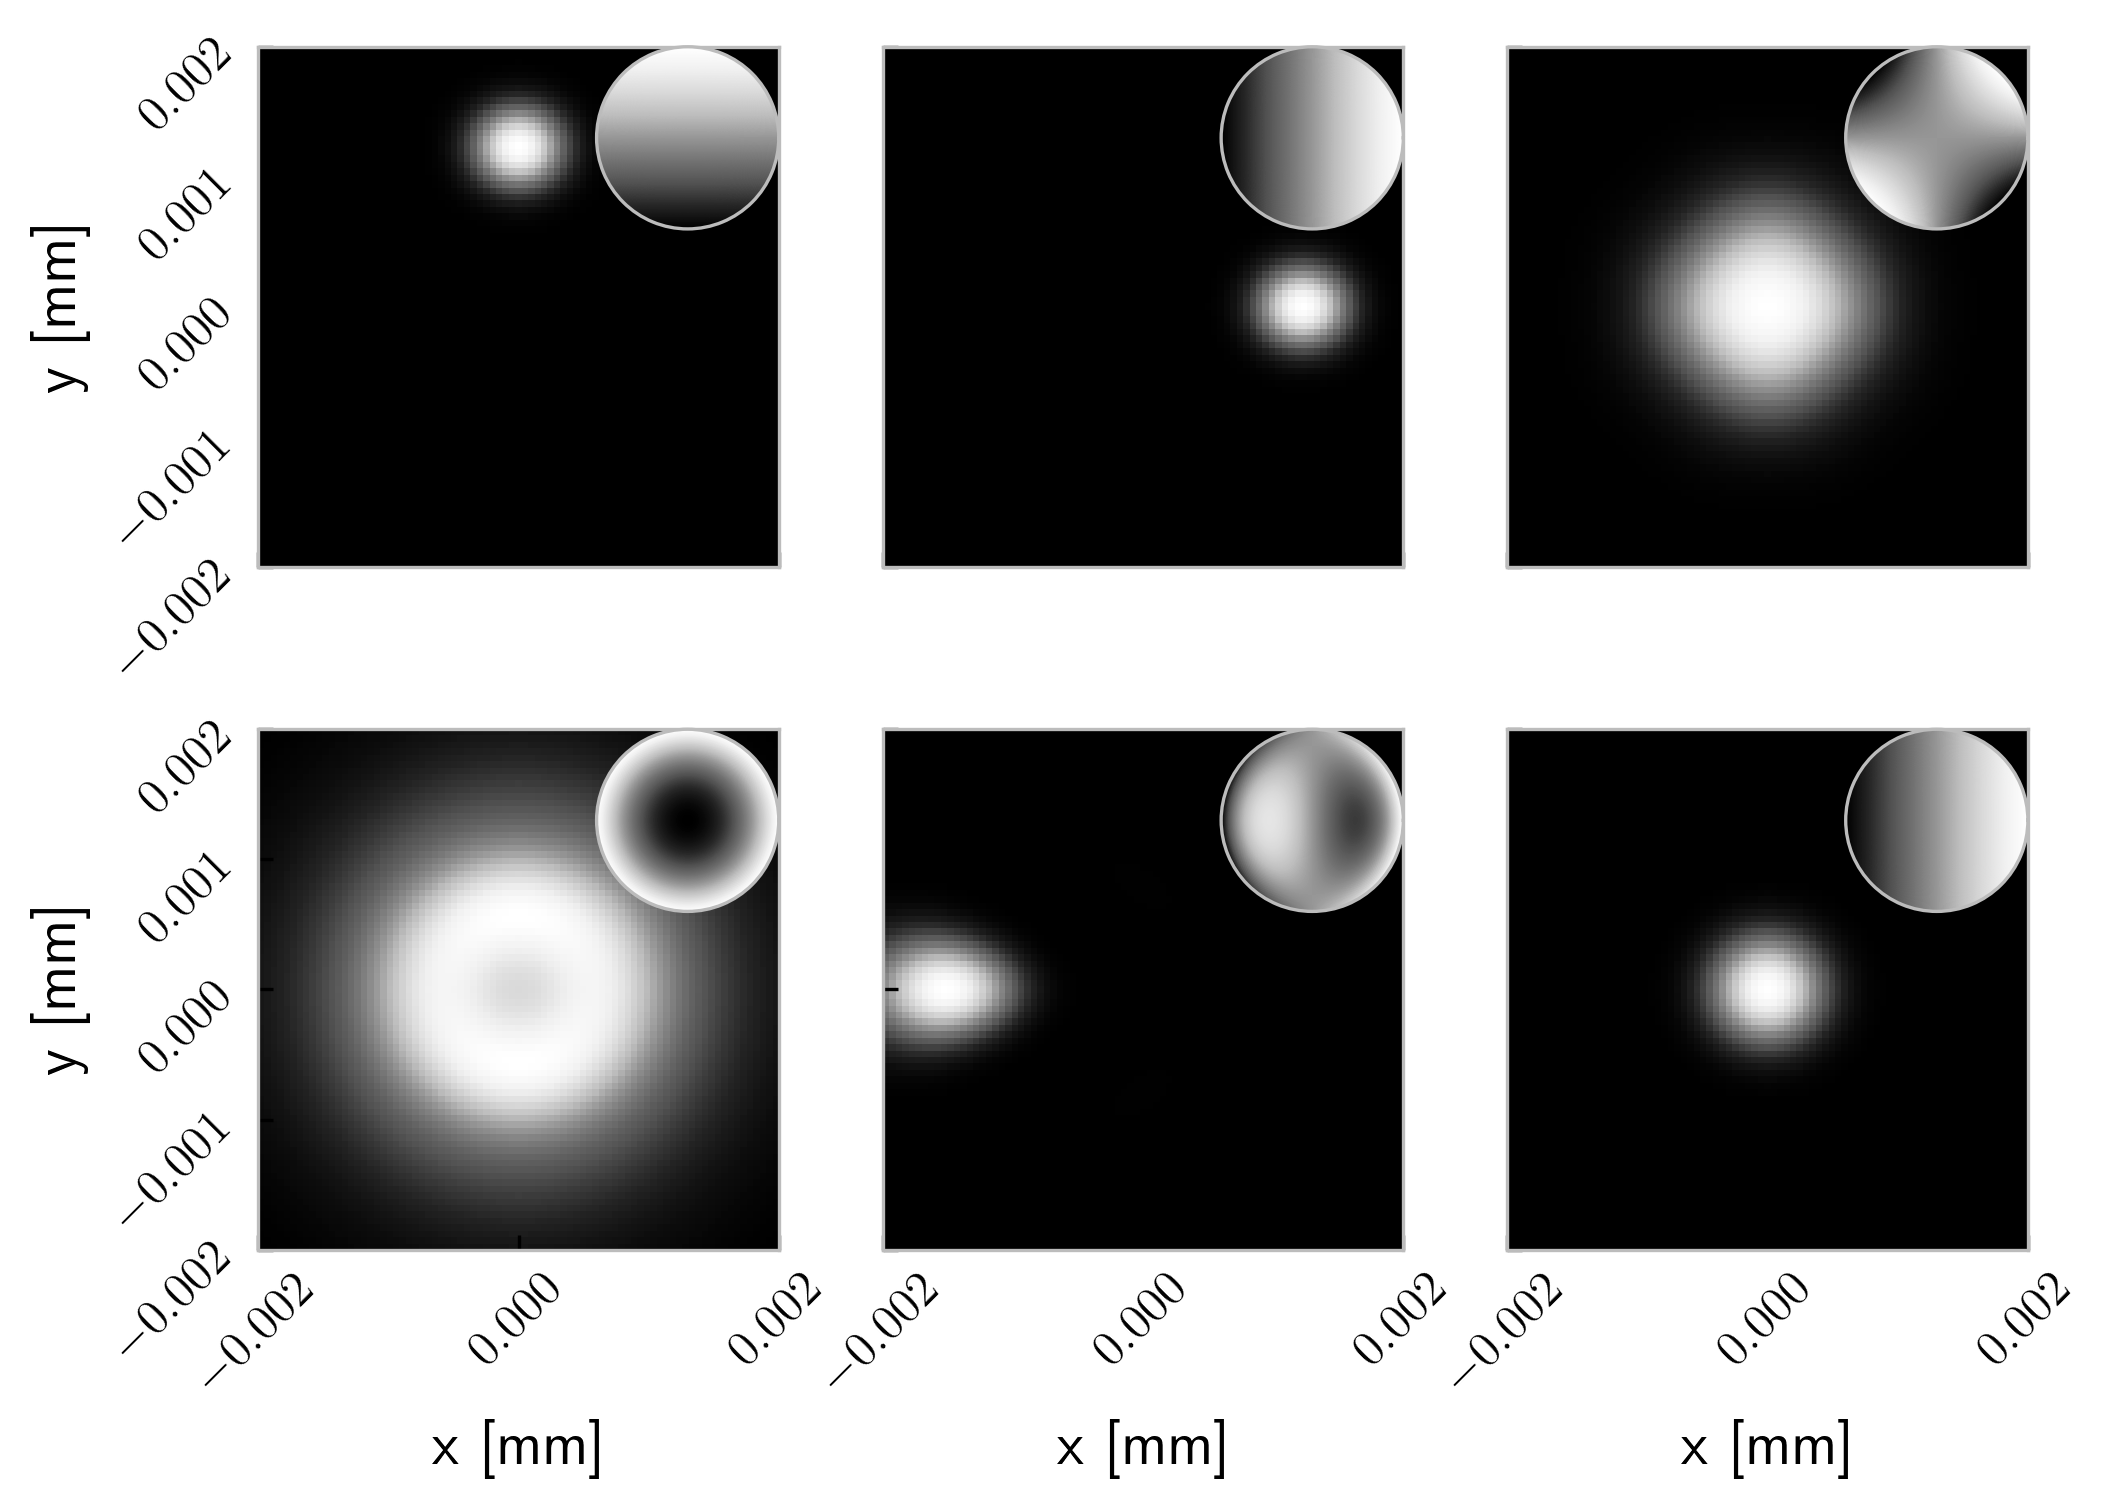

In [56]:
fig, axs = plt.subplots(2, 3, sharey = True, sharex = True)
PH.many_composite(fig, axs[0], x_1, y_1, [I_4, I_5, I_6], [z_map_4, z_map_5, z_map_6], alpha, is_edge = False, is_horizontal = True)
PH.many_composite(fig, axs[1], x_1, y_1, [I_2, I_1, I_3], [z_map_2, z_map_1, z_map_3], alpha, is_edge = True, is_horizontal = True)
plt.savefig("benchmarking_figures/some_sample_aberrations.png", bbox_inches = "tight")

In [45]:
seeds = [1, 2, 3, 4, 5, 6]
Is = []
z_maps = []
num_orders = 15
scaling = 0.5
for i in range(6):
    modes, strengths = ZH.generate_random_aberration(seeds[i], num_orders, scaling)
    z_map = ZH.create_zernike_function(modes, strengths, alpha)
    x_c, y_c, I_c = RH.parallel_grid_wrapper(L_ffp, grid_ffp, alpha, k, f, n, fwhm_pupil, theta_grid_size, N_order,"Zernike", "parallel_output/psf_output.npz", [modes.tolist(), strengths.tolist()])
    Is.append(I_c)
    z_maps.append(z_map)

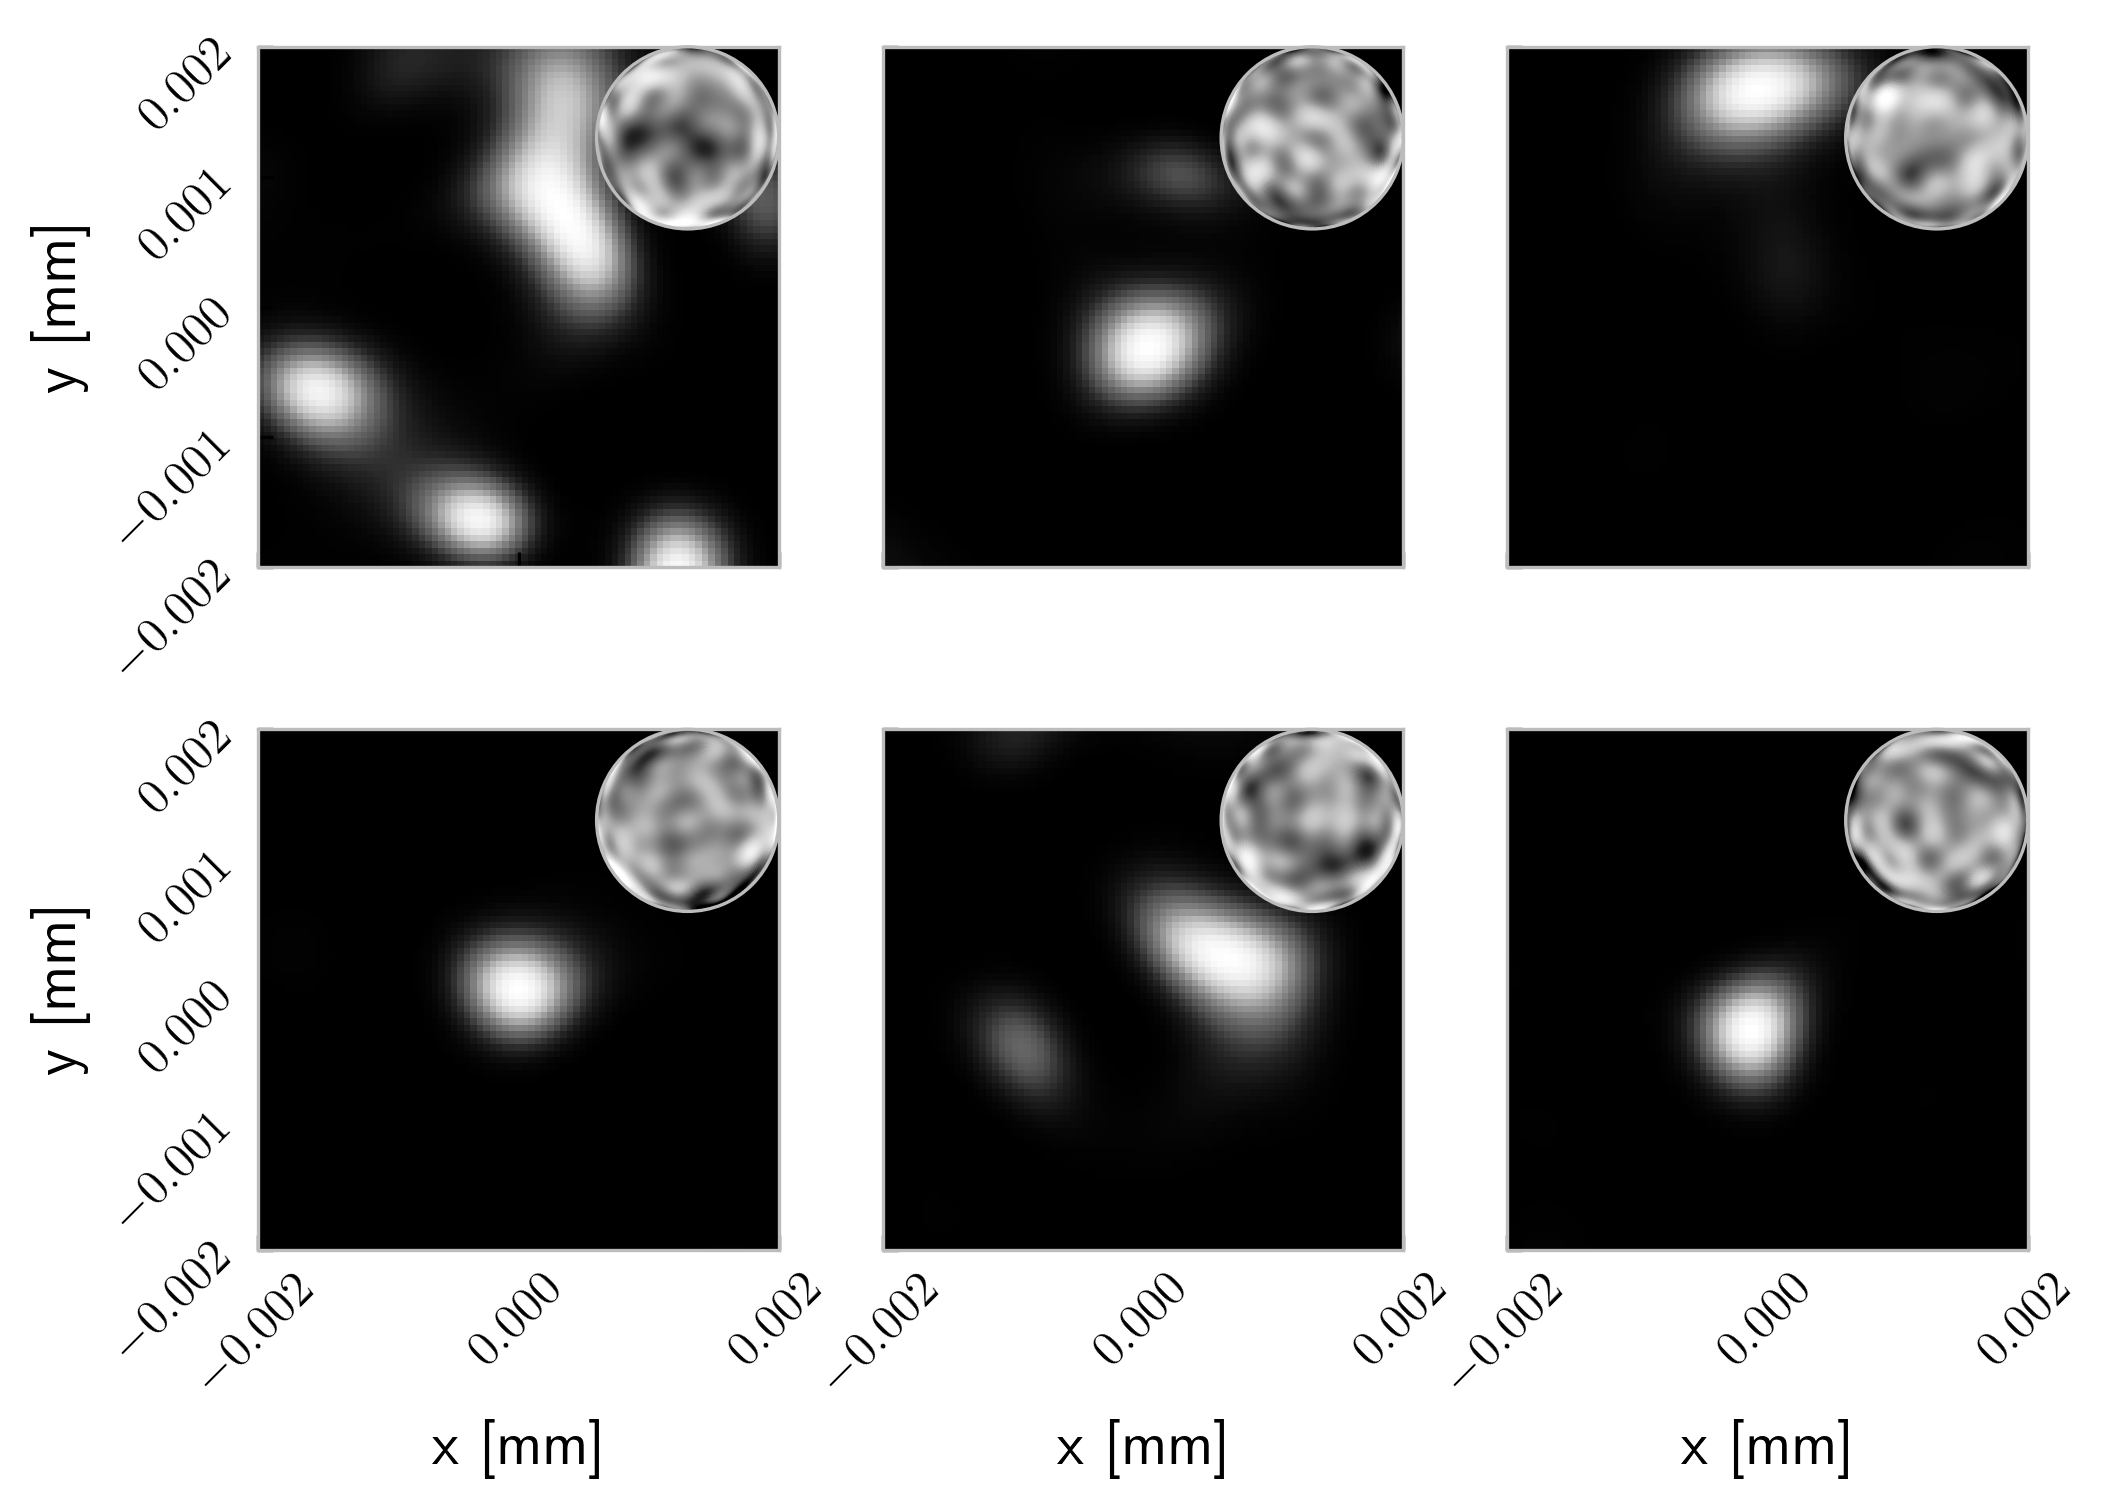

In [57]:
fig, axs = plt.subplots(2, 3, sharey = True, sharex = True)
PH.many_composite(fig, axs[0], x_1, y_1, [Is[i] for i in range(0, 4)], [z_maps[i] for i in range(0,4)], alpha, is_edge = False, is_horizontal = True)
PH.many_composite(fig, axs[1], x_1, y_1, [Is[i] for i in range(3, 6)], [z_maps[i] for i in range(3,6)], alpha, is_edge = True, is_horizontal = True)
plt.savefig("benchmarking_figures/random_aberrations.png", bbox_inches = "tight")